<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Unsupervised Learning: Trade & Ahead</font></center>

<center><img src="https://wpblogassets.paytm.com/paytmblog/uploads/2023/08/Blogs_Paytm_Bond-Market-vs.-Stock-Market_-Whats-the-Difference_-1.jpg" width="800" height="500"></center>

<center><font size=6>Clustering Stocks for Diversified Portfolio Construction</font></center>

# **1. Problem Statement**

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange.

They have assigned you the tasks of:
- analyzing the data,
- grouping the stocks based on the attributes provided,
- and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: (Price-to-Earnings) Ratio of the company's current stock price to the earnings per share.
- P/B Ratio: (Price-to-Book) Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

### Features
1. Ticker, Company, GICS are **identifiers**.
2. Current Price, Price Change, Volatility reflect **stock market behavior**.
3. ROE, Net Income, EPS measure **profitability**.
4. Cash Ratio, Net Cash Flow captures **liquidity and financial health**.
5. Shares Outstanding, P/E, P/B are **valuation metrics used to compare companies**.

# **2. Importing necessary libraries and data**

In [1]:
# Installing necessary libraries
# for reading and manipulating data
import numpy as np
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# removing the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# setting the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# for scaling the data using z-score
from sklearn.preprocessing import StandardScaler, RobustScaler

# for computing distances
from scipy.spatial.distance import cdist, pdist

# tfor performing k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# for visualizing the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# for performing hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

# **3. Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Module 6 Unsupervised Learning/Week 3/stock_data.csv')

In [5]:
df = data.copy()

# **4. Overview of the Dataset**

In [6]:
df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [7]:
df.tail()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
335,YHOO,Yahoo Inc.,Information Technology,Internet Software & Services,33.259998,14.887727,1.845149,15,459,-1032187000,-4359082000,-4.64,939457327.6,28.976191,6.261775
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,435353535.4,17.682214,-3.838260
337,ZBH,Zimmer Biomet Holdings,Health Care,Health Care Equipment,102.589996,9.347683,1.404206,1,100,376000000,147000000,0.78,188461538.5,131.525636,-23.884449
338,ZION,Zions Bancorp,Financials,Regional Banks,27.299999,-1.158588,1.468176,4,99,-43623000,309471000,1.20,257892500.0,22.749999,-0.063096
339,ZTS,Zoetis,Health Care,Pharmaceuticals,47.919998,16.678836,1.610285,32,65,272000000,339000000,0.68,498529411.8,70.470585,1.723068


In [8]:
# Viewing a random sample of the dataset
df.sample(n=10, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620


In [9]:
df.shape

(340, 15)

- There are 350 observations (rows) and 15 features (columns) in this dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

- Four of the features are of object data type while eleven features are numeric (int or float).
- All of the features have the expected data type.

In [11]:
df.isnull().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


In [12]:
df.duplicated().sum()

np.int64(0)

- There are neither missing nor duplicated observations in the dataset.

# **5. Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.

**Leading Questions**

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

### **5.1. Statistical Summary of the Data**

In [13]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.00,80.86,98.06,4.50,38.55,59.70,92.88,1274.95
Price Change,340.00,4.08,12.01,-47.13,-0.94,4.82,10.70,55.05
Volatility,340.00,1.53,0.59,0.73,1.13,1.39,1.70,4.58
ROE,340.00,39.60,96.55,1.00,9.75,15.00,27.00,917.00
Cash Ratio,340.00,70.02,90.42,0.00,18.00,47.00,99.00,958.00
Net Cash Flow,340.00,55537620.59,1946365312.18,-11208000000.00,-193906500.00,2098000.00,169810750.00,20764000000.00
Net Income,340.00,1494384602.94,3940150279.33,-23528000000.00,352301250.00,707336000.00,1899000000.00,24442000000.00
Earnings Per Share,340.00,2.78,6.59,-61.20,1.56,2.90,4.62,50.09
Estimated Shares Outstanding,340.00,577028337.75,845849595.42,27672156.86,158848216.10,309675137.80,573117457.32,6159292035.00
P/E Ratio,340.00,32.61,44.35,2.94,15.04,20.82,31.76,528.04


- The numeric features are in different scales. For example, the average net income is 1.49 billion USD whereas the average volatility is 1.53 USD. In order to prevent features with relatively high scales from dominating the clustering alrgorithms, all numeric features must be standardized before clustering.
- Most features' distribution is heavily right-skewed (mean > median): Current Price, Volatility, ROE, Cash Ratio, Net Cash Flow, Net Income, Estimated Shares Outstanding, P/E Ratio.
- A few features are slighlt left-skewed (mean < median): Price Change, Earnings Per Share, P/B Ratio.




In [14]:
df.describe(include='object').T

,count,unique,top,freq
Ticker Symbol,340,340,ZTS,1
Security,340,340,Zoetis,1
GICS Sector,340,11,Industrials,53
GICS Sub Industry,340,104,Oil & Gas Exploration & Production,16


- Ticker Symbol and Security are unique IDs with 340 unique values out of 340 counts so they do not need to be analyzed.
- GICS Sector has 11 unique values while the GICS Sub Industry has 104 of them.
- Industrials is the most common GICS sector (15.6%) of the dataset, whereas Oil & Gas Exploration & Production is the most prevalent GIC Sub Industry (4.6%).

### **5.2. Univariate Analysis**

#### Numeric Features

In [15]:
# Function to plot both a boxplot and histogram for a single numeric feature.
# Helps visualize the distribution, detect skewness, and identify outliers, with mean and median lines for reference.

def histogram_boxplot(df, feature, figsize=(8, 5), kde=False, bins=None):
    """
    Plotting a boxplot and histogram for a single numeric feature.

    Parameters:
    - data: DataFrame containing the data.
    - feature: The column name of the feature to plot.
    - figsize: Tuple controlling the figure size.
    - kde: Choosing whether to overlay a kernel density estimate on the histogram.
    - bins: Setting the number of bins for the histogram (optional).
    """

    # Skipping if the feature is not numeric
    if not pd.api.types.is_numeric_dtype(df[feature]):
        print(f"Skipping non-numeric column: {feature}")
        return

    # Creating a figure with 2 subplots stacked vertically
    # Using the first for the boxplot, the second for the histogram; sharing the x-axis
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,  # Defining two rows: one for the boxplot, one for the histogram
        sharex=True,  # Sharing the x-axis between both plots
        gridspec_kw={"height_ratios": (0.25, 0.75)},  # Assigning less vertical space to the boxplot
        figsize=figsize  # Setting the overall figure size
    )

    # Plotting the boxplot on the top subplot
    sns.boxplot(data=df, x=feature, ax=ax_box, showmeans=True, color="violet")

    # Plotting the histogram on the bottom subplot
    sns.histplot(data=df, x=feature, kde=kde, ax=ax_hist, bins=bins)

    # Adding a vertical line showing the mean of the feature
    ax_hist.axvline(df[feature].mean(), color="green", linestyle="--", label="Mean")

    # Adding a vertical line showing the median of the feature
    ax_hist.axvline(df[feature].median(), color="black", linestyle="-", label="Median")

    # Showing the legend for mean and median lines
    ax_hist.legend()

    # Adding a title at the top of the figure
    plt.suptitle(f"Histogram & Boxplot for '{feature}'", fontsize=16)

    # Adjusting layout to prevent overlap
    plt.tight_layout()

    # Displaying the final plot
    plt.show()

In [16]:
# Function to automatically generate boxplot + histogram visualizations.

def auto_histogram_boxplot(df, features=None, **kwargs):
    """
    Runs histogram_boxplot for multiple features.

    features: list of column names to plot; if None, auto-selects numeric columns
    kwargs: passed to histogram_boxplot (e.g., figsize, kde, bins)

    Adds visual dividers between plots.
    """
    if features is None:
        features = df.select_dtypes(include='number').columns

    for feature in features:
        print("\n" + "=" * 160)
        print(f"    ")
        print("=" * 160 + "\n")
        histogram_boxplot(df, feature, **kwargs)

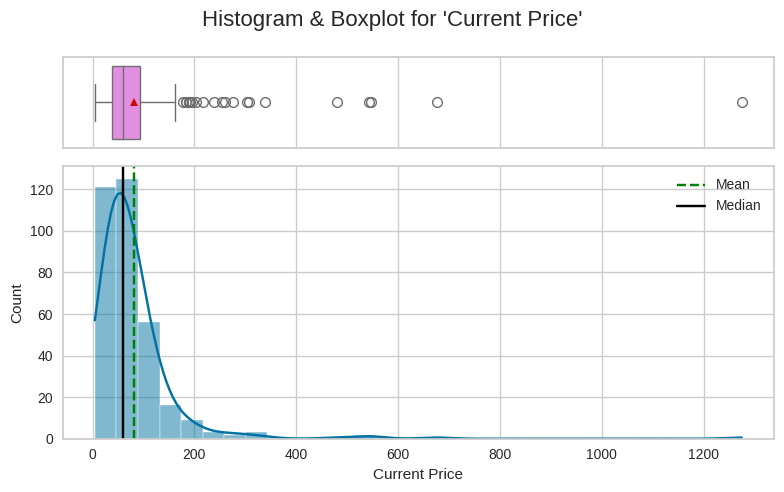

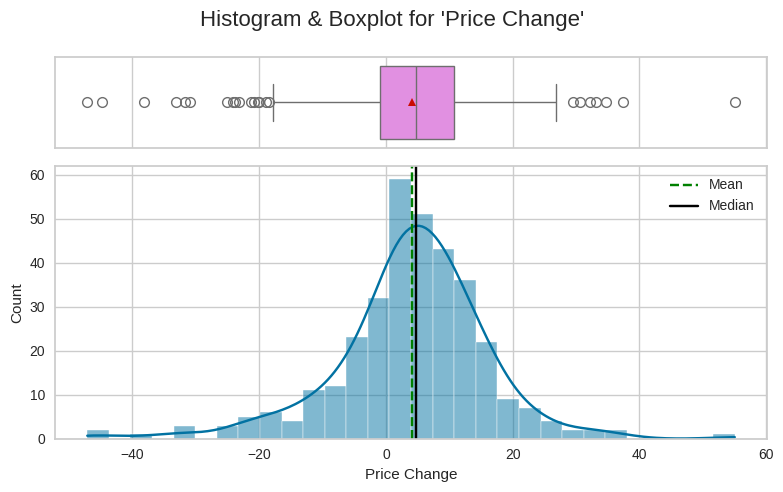

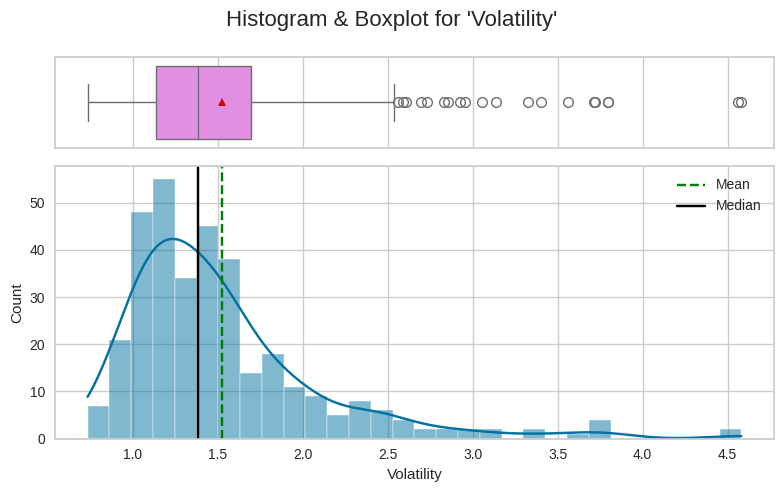

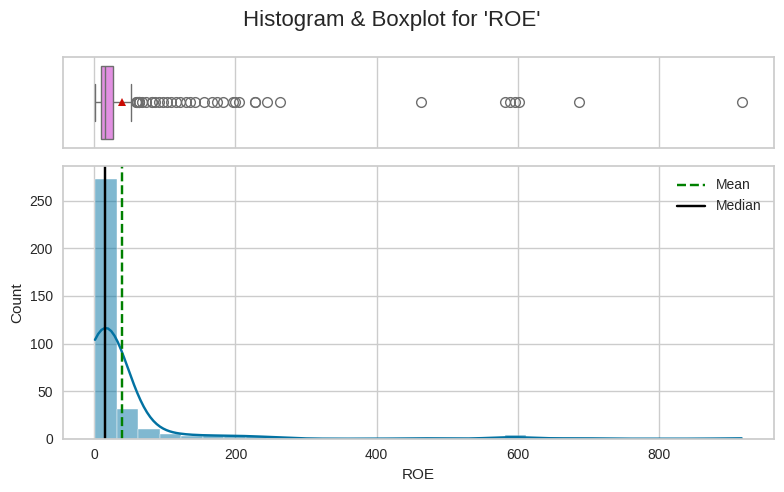

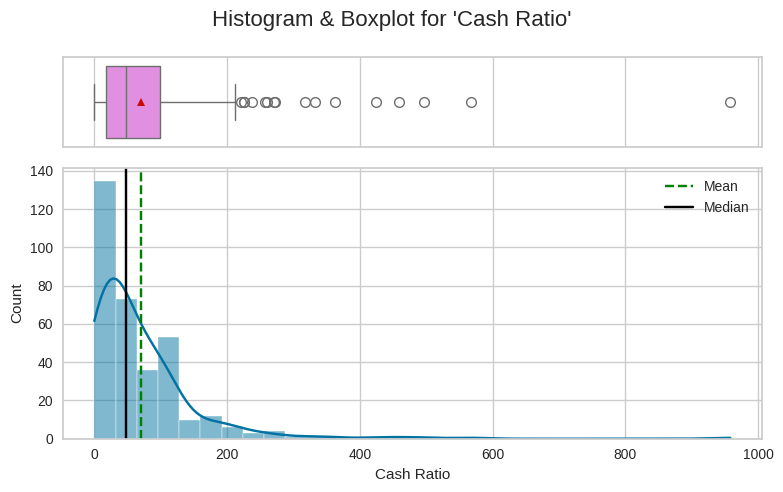

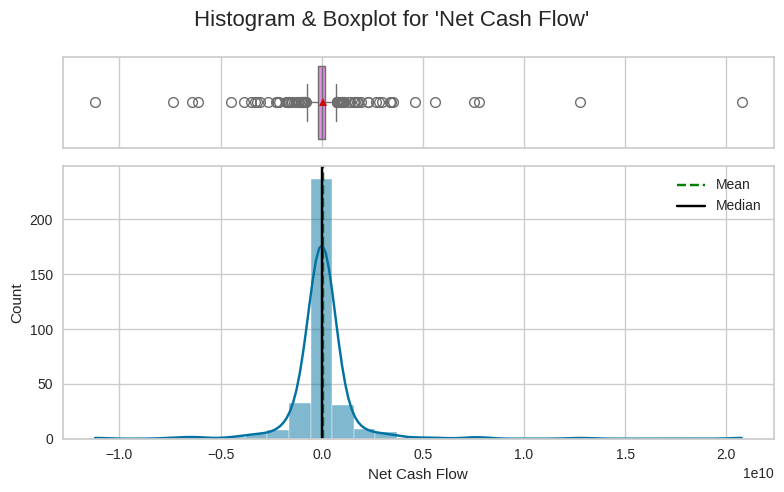

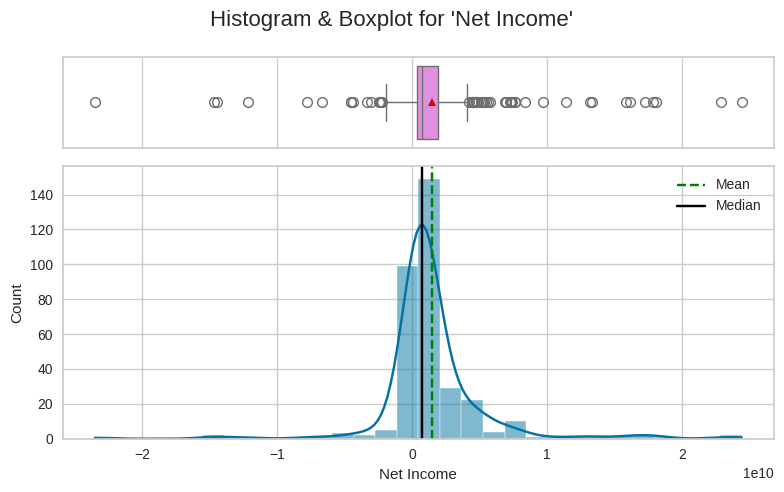

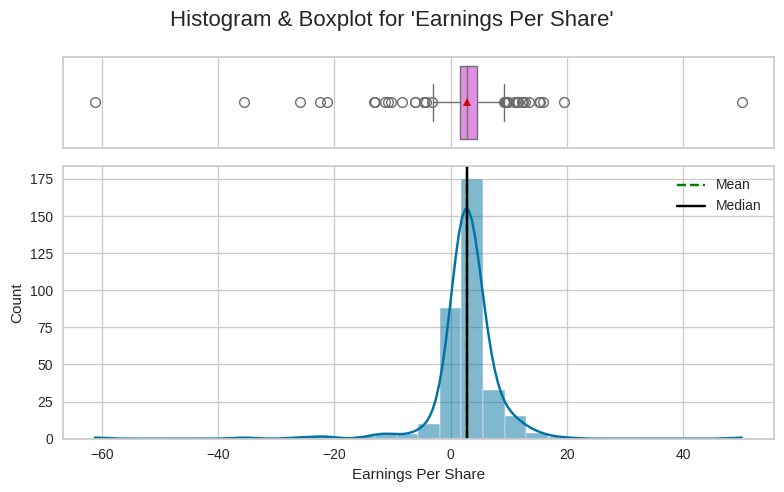

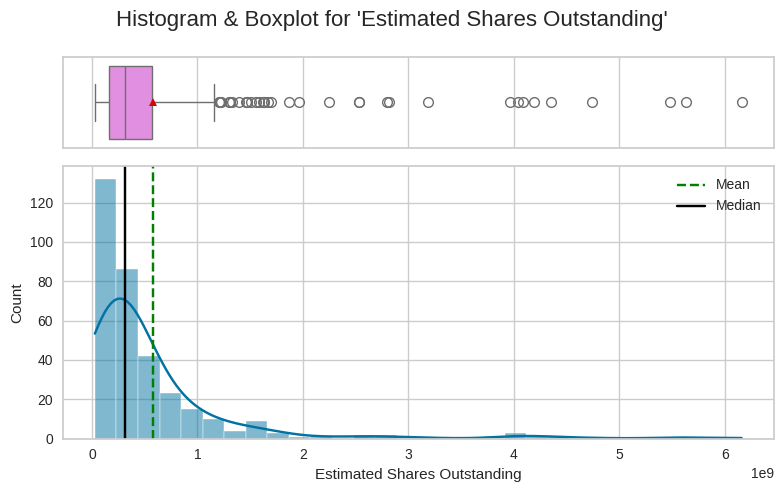

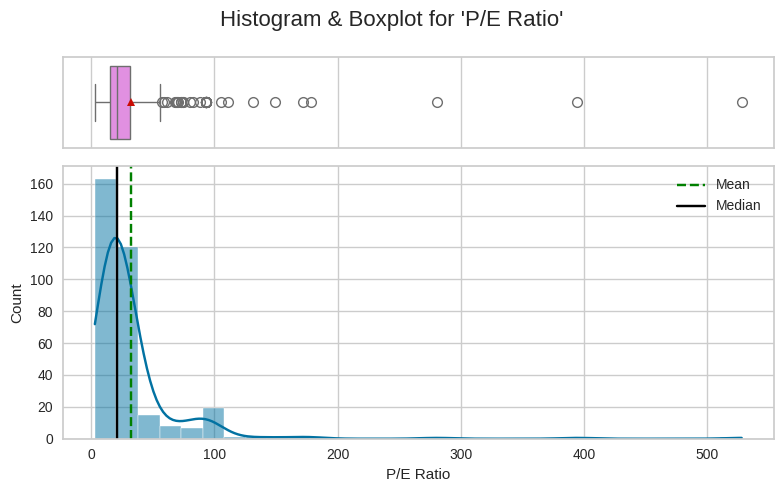

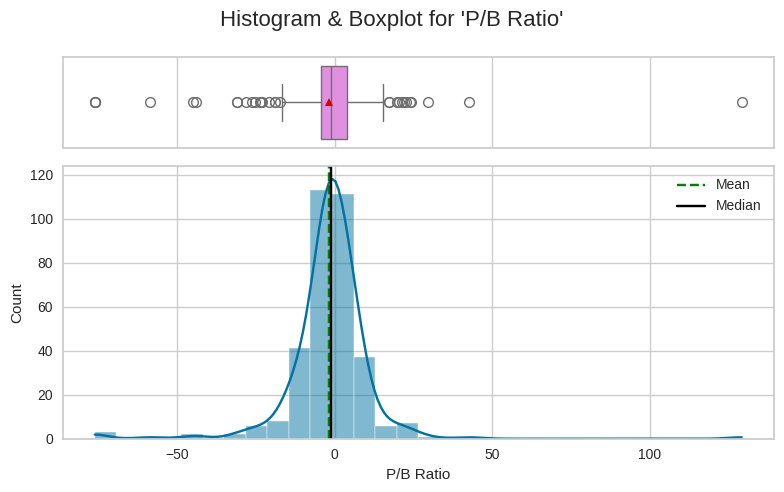

In [17]:
auto_histogram_boxplot(df, kde=True, bins=30)

**Question # 1**. What does the distribution of stock prices look like?

- The Current Price distribution is heavily right-skewed (mean > median) as shown by the histogram and the boxplot.
- Most companies have low-priced stocks as shown by the tight IQR of the boxplot, but a small number of very expensive stocks (e.g., > 600 USD, > 1200 USD) stretch the mean upward and create a long right tail.
- The range is very wide (some stocks priced above 1200 USD while most are below 100 USD).
- The distribution is non-Gaussian since it’s not symmetric or bell-shaped.


#### Observations on Numeric Features
- **Features with right-skewed distribution:** Current Price, Volatility, ROE, Cash Ratio, Estimated Shares, P/E.
- **Features with heavy-tailed (but roughly symmetric) distribution:** Net Cash Flow, Net Income, EPS, P/B Ratio.
- **Feature with near-Gaussian but high kurtosis (fat tails) distribution:** Price Change.

----------------------------------------------------------------------------
Clustering algorithms like K-Means or Hierarchical Clustering use distance metrics. If one feature is highly skewed or heavy-tailed, distances are dominated by its outliers. This means that Clustering algorithms are sensitive to outliers, which can lead to poorly separated clusters.

Based on the observations above, we can apply the following transformations in order to treat the outliers:

1. **log1p for strictly positive, right-skewed distributions** (e.g., Current Price, Estimated Shares, Volatility, Cash Ratio).

Log1p transformation helps address skewness in strictly positive variables by compressing large values and stretching smaller ones, which makes the distribution closer to symmetric. This reduces the influence of extreme outliers and ensures that features with heavy right tails (like stock prices or company size) do not dominate the distance calculations in clustering.

2. **Yeo-Johnson for distributions with negative values or are heavy-tailed** (e.g., Net Income, Net Cash Flow, EPS, Price Change, P/B).

Similarly, Yeo–Johnson transformation helps address negative skewness and heavy-tailed distributions by reshaping the distribution to be closer to Gaussian (bell-shaped), so each feature contributes more fairly to distance calculations.

#### Categorical Features

In [18]:
# Function to create a barplot for a categorical feature, displaying either raw counts or percentages as labels on each bar.

def labeled_barplot(df, feature, perc=False, n=None, title=None, palette='viridis'):
    """
    Creating a barplot with counts or percentages labeled on top.

    Parameters:
    - data: the DataFrame
    - feature: the categorical column to plot
    - perc: setting True will display percentages instead of counts
    - n: limiting to top n most frequent categories
    - palette: colormap for the barplot
    """
    # Calculating total number of values for percentage calculation
    total = len(df[feature])

    # Counting the number of unique category levels
    count = df[feature].nunique()

    # Setting figure size based on number of categories (or top n)
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    # Rotating x-axis labels for readability and setting font size
    plt.xticks(rotation=90, fontsize=15)

    # Creating a barplot ordered by frequency
    ax = sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index[:n],
        palette=palette # Added palette parameter here
    )

    # Looping through each bar to annotate with count or percentage
    for p in ax.patches:
        if perc == True:
            # Calculating and formatting percentage label
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            # Using raw count as label
            label = p.get_height()

        # Calculating x and y positions for label placement
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        # Adding the label above the bar
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    # Adding a title to the barplot
    if title is None:
      plt.title(f"Barplot for '{feature}'", fontsize=16)
    else:
      plt.title(title, fontsize=16)


    # Displaying the plot
    plt.show()

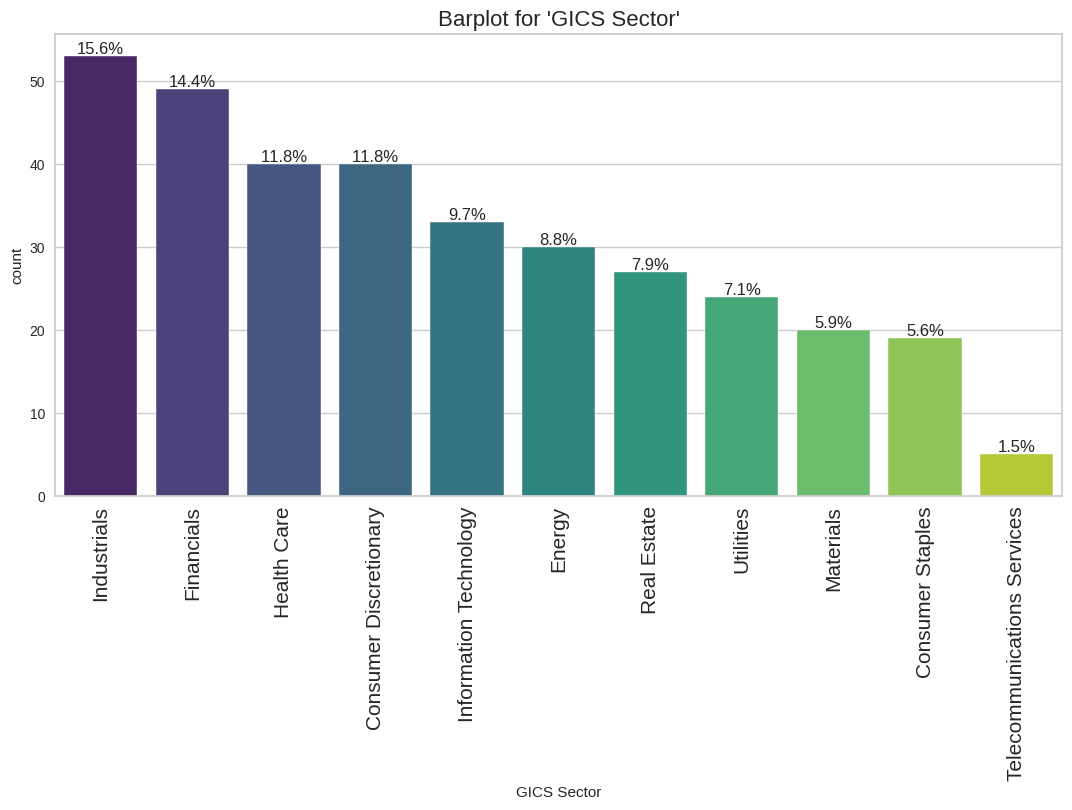

In [19]:
labeled_barplot(df, 'GICS Sector', perc=True)

- The dataset has broad sector coverage, but some sectors dominate (Industrials & Financials represent nearly 1/3 of the data).
- Smaller sectors, especially Telecommunications (1.5%), may be underrepresented in clustering, making them less influential in forming distinct groups.
- Since `GICS Sector` are categorical descriptors and highly imbalanced, they’re better used as labels for interpretation after clustering rather than as direct input features.

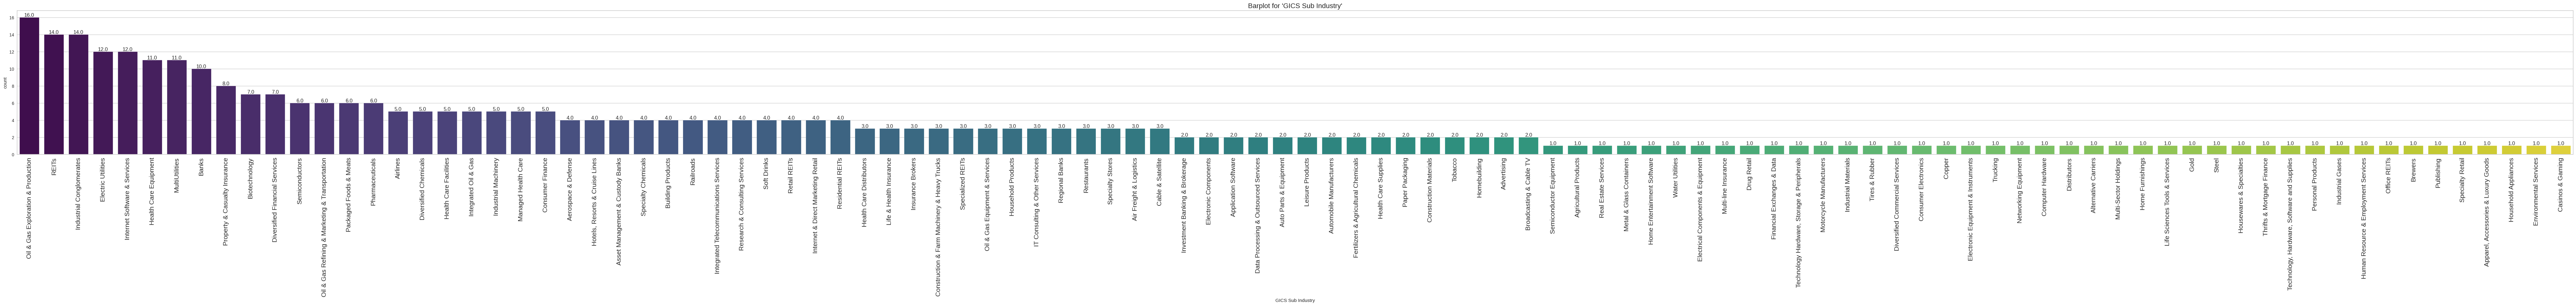

In [20]:
labeled_barplot(df, 'GICS Sub Industry')

In [21]:
# Get the value counts for the 'GICS Sub Industry' column
sub_industry_counts = df['GICS Sub Industry'].value_counts()

# Filter for sub-industries with a count of 1 and count them
num_sub_industries_with_one_count = (sub_industry_counts == 1).sum()

print(f"The number of GICS Sub Industries with only one count is: {num_sub_industries_with_one_count}")

The number of GICS Sub Industries with only one count is: 42


- Top GICS sub-industries are oil and gas exploration and production (16 companies), REITs (14), and industrial conglomerates (14), while 42 sub-industries only have 1 company in it.

- Similar to `GICS Sector`, `GICS Sub Industry` covers a wide range of sub-industries, but the distribution is highly imbalanced.

- A few sub-industries dominate the sample. For instance, `Oil & Gas Exploration & Production`, ` Real Estate Investment Trust`, and `Electric Utilities` account for 56% of the companies in the dataset.

- Most other sub-industries have a much smaller presence, with many contributing only a handful of firms.

- This imbalance suggests that clustering may naturally group firms around these dominant sectors, while smaller sub-industries may not form strong clusters on their own.

- As with `GICS Sector`, this variable works best as a label for interpretation rather than an input feature, since clustering already uses numeric financial indicators.

## **5.3. Bivariate Analysis**

### Heatmap Correlation (Numeric Features)

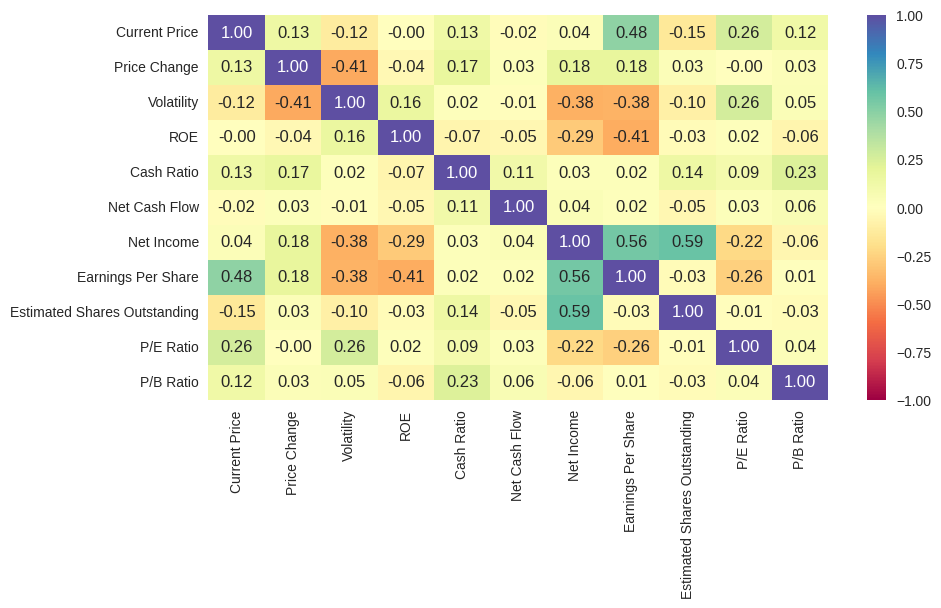

In [22]:
# Selecting numeric features to plot a heatmap of correlation
num_cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[num_cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Question # 3**. How are the different variables correlated with each other?

- Volatility shows moderate negative correlations with profitability metrics (EPS, Net Income), suggesting less stable firms perform worse financially.

- EPS is moderately aligned with price and net income, making it a useful summary variable.

- Valuation ratios (P/E and P/B) do not strongly correlate with fundamental metrics here, perhaps indicating market mispricing or noise.

- Cash Ratio, Net Cash Flow, and ROE appear largely uncorrelated with price-related metrics and might require transformation or exclusion from certain models like K-Means.

### Functions for Plotting

In [23]:
def plot_average_by_category(df, categorical_col, numerical_col):
    """
    Plots the average of a numerical column by a categorical column,
    ordered from highest to lowest average, with value labels on each bar.

    Args:
        df: pandas DataFrame.
        categorical_col: The name of the categorical column.
        numerical_col: The name of the numerical column.
    """
    plt.figure(figsize=(15, 8))
    # Calculate the mean of the numerical column for each category and sort in descending order
    avg_by_category = df.groupby(categorical_col)[numerical_col].mean().sort_values(ascending=False)
    # Create the barplot
    ax = sns.barplot(x=avg_by_category.index, y=avg_by_category.values, ci=False, palette='viridis')
    plt.xticks(rotation=90)

    # Add value labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.title(f'Average {numerical_col} by {categorical_col}')
    plt.show()

### Price Change vs GICS Sector

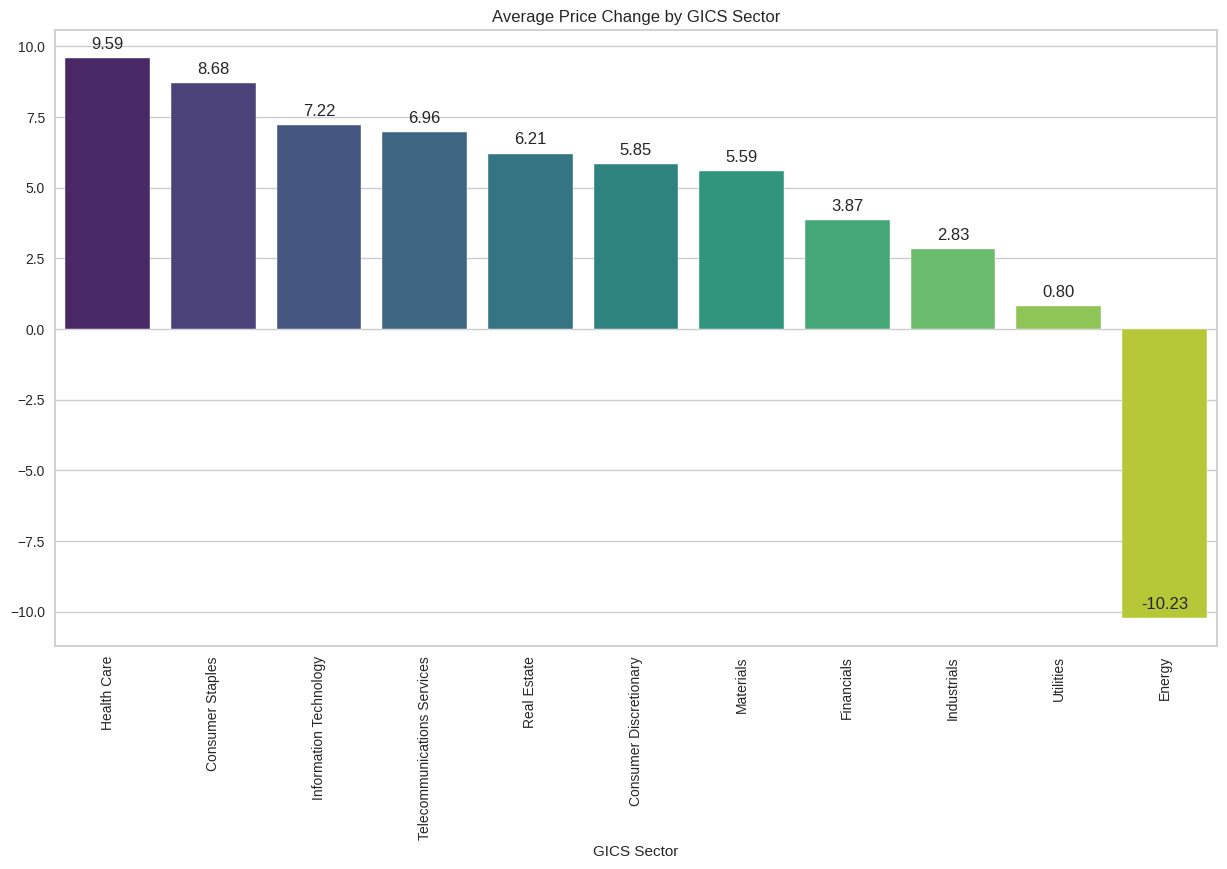

In [24]:
plot_average_by_category(df, 'GICS Sector', 'Price Change')

**Question # 2**. The stocks of which economic sector have seen the maximum price increase on average?

- Health Care (+9.6%) and Consumer Staples (+8.7%) show the strongest average growth.

- Most sectors show positive price change, though at varying levels.

- Energy (−10.2%) is the only sector with a negative average, standing out as a clear underperformer. This might lead to a separate cluster for Energy stocks due to their negative momentum.

- This also informs us that the dataset might have been taken anytime between 2014 and 2016 - recent period of major oil price collapse.

### GICS Sector vs Cash Ratio

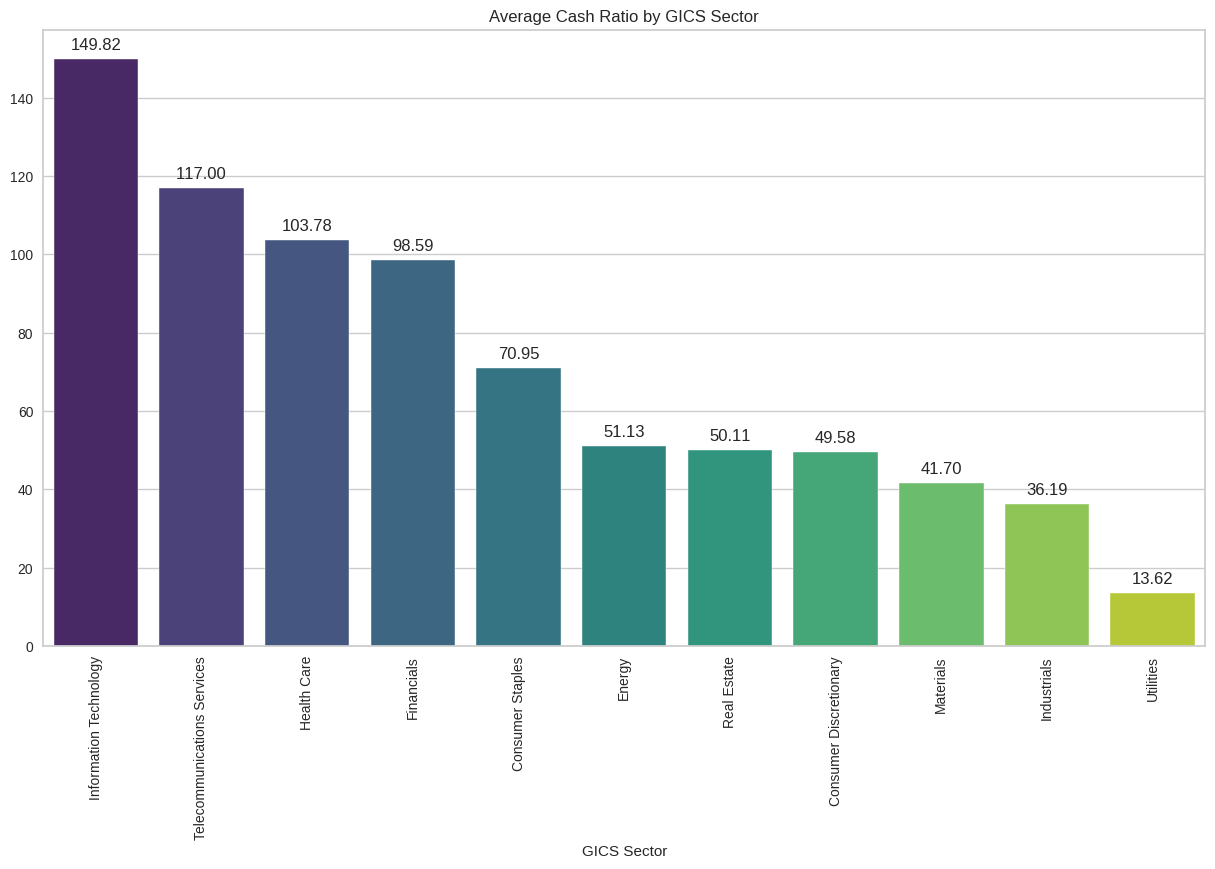

In [25]:
plot_average_by_category(df, 'GICS Sector', 'Cash Ratio')

**Question # 4**. How does the average cash ratio vary across economic sectors?

- Companies with higher cash ratio are able to cover their short-term expenses using cash (liquid assets).

- Cash Ratio is the highest in Information Technology (149.8 USD) and Telecommunications (117.0 USD), suggesting strong short-term financial safety.

- Utilities (13.6) and Industrials (36.2) are on the opposite end, operating with thinner cash reserves.

- The distinct differences in Cash Ratio (liquidity) may drive separation of cash-rich IT/Telecom firms vs. capital-intensive sectors like Utilities.

### GICS Sector vs P/E Ratio

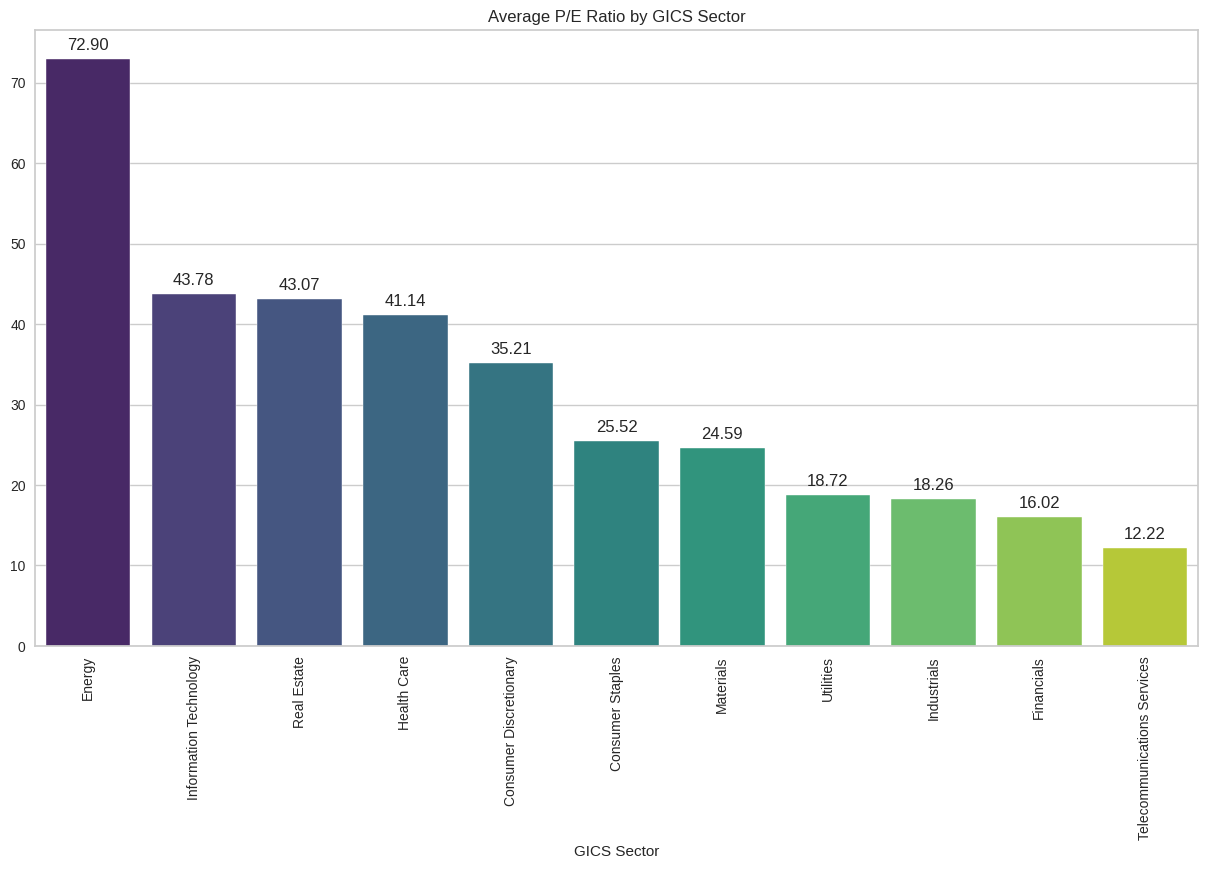

In [26]:
plot_average_by_category(df, 'GICS Sector', 'P/E Ratio')

**Question # 5**. How does the P/E ratio vary, on average, across economic sectors?

- P/E ratios signify the how much an investor is willing to invest in a single share of a company per dollar of its earnings.
- Stocks in the Energy sector stands out with the highest average P/E Ratio compared to other sectors at 72.9, likely due to weak earnings relative to stock price.

- Tech (43.8) and Real Estate (43.1) also show elevated valuations.

- Telecom (12.2), Financials (16.0), and Industrials (16.0) sit on the low end.

- Valuation metrics may create divides between “growth” sectors (e.g., Tech, Energy) and “value” sectors (e.g., Financials, Industrials).

### GICS Sector vs Volatility

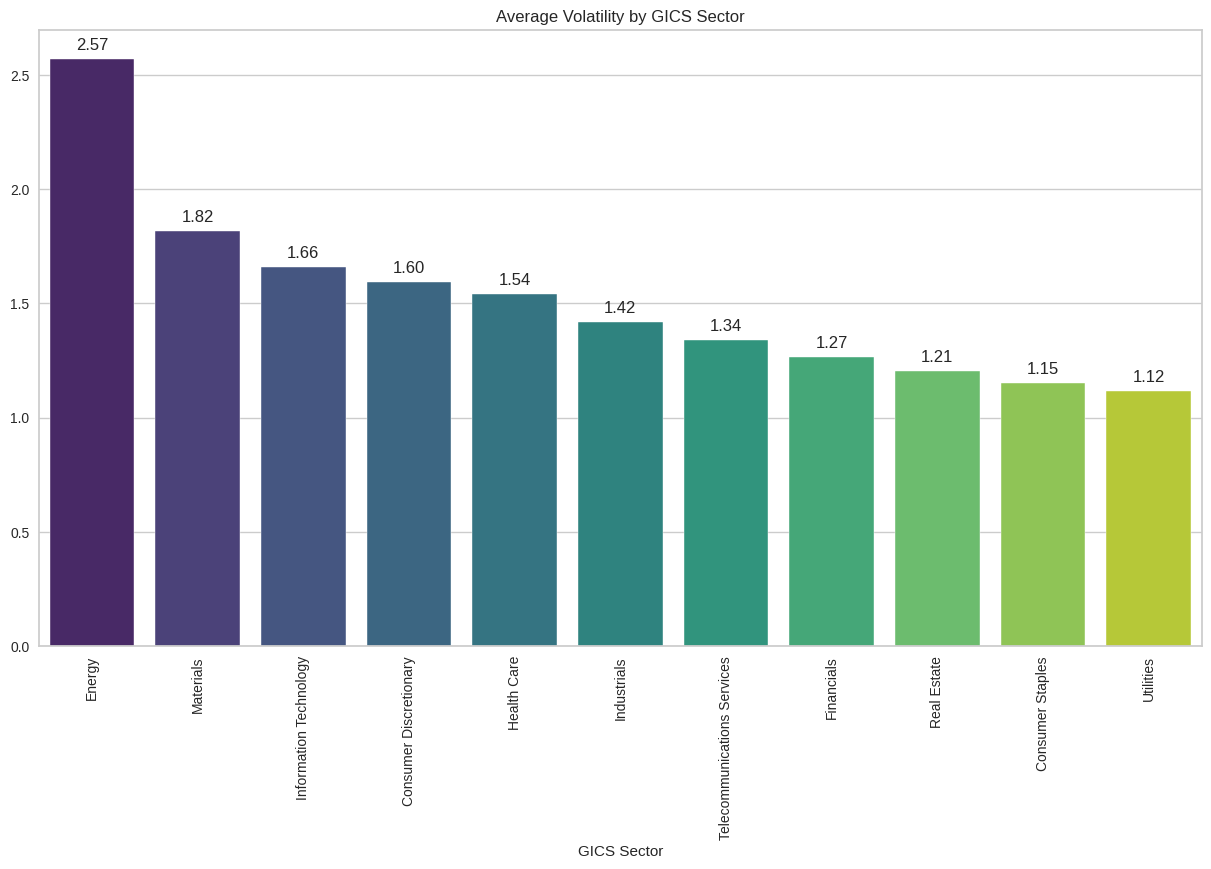

In [27]:
plot_average_by_category(df, 'GICS Sector', 'Volatility')

- Energy (2.57) and Materials (1.82) are the most volatile sectors, implying steeper stock price fluctuations (i.e., less stable investments)

- On the other hand, Utilities (1.12) and Consumer Staples (1.15) are the most stable, reflecting their defensive nature.

- In our clustering algorithms, `Volatility` will likely distinguish “high-risk” sectors (Energy, Materials) from “defensive” ones (Utilities, Staples).

### Summary of Observations in Bivariate Analysis

-  Energy sector is consistently an outlier: negative returns, very high P/E, and highest volatility. This could lead to the formations of its own distinct cluster.

- Tech & Telecom show liquidity strength and higher valuations, hence, they may cluster together.

- Defensive or stable sectors (e.g., Utilities, Consumer Staples) combine low volatility with stable returns. This may form another group.

- Financials & Industrials appear mid-range across most metrics, potentially clustering near the center.

- Overall, we are expecting more or less 4 clusters.


# **6. Methodology**

In this study, we will perform and compare the results of two clustering algorithms:
1. Centroid-based: K-Means Clustering
2. Connectivity-based: Hierarchal Clustering (specifically, Agglomerative)

In addition, we will also investigate the impact of variable transformations on clusterings (e.g., log1 and Yeo-Johnson transformations) (Approach 2). We will do so by comparing it a control study where clustering is conducted on non-transformed features (Approach 1). This methodology will demonstrate to what extent clustering algorithms are sensitive to outliers and how treatment of variables can impact the clustering results.

# **7. Approach 1 : Clustering on Non-Transformed Features**

## **Data Pre-processing**

### **Outlier Detection and Treatment**

- We're plotting boxplots of all numerical columns to observe outliers.

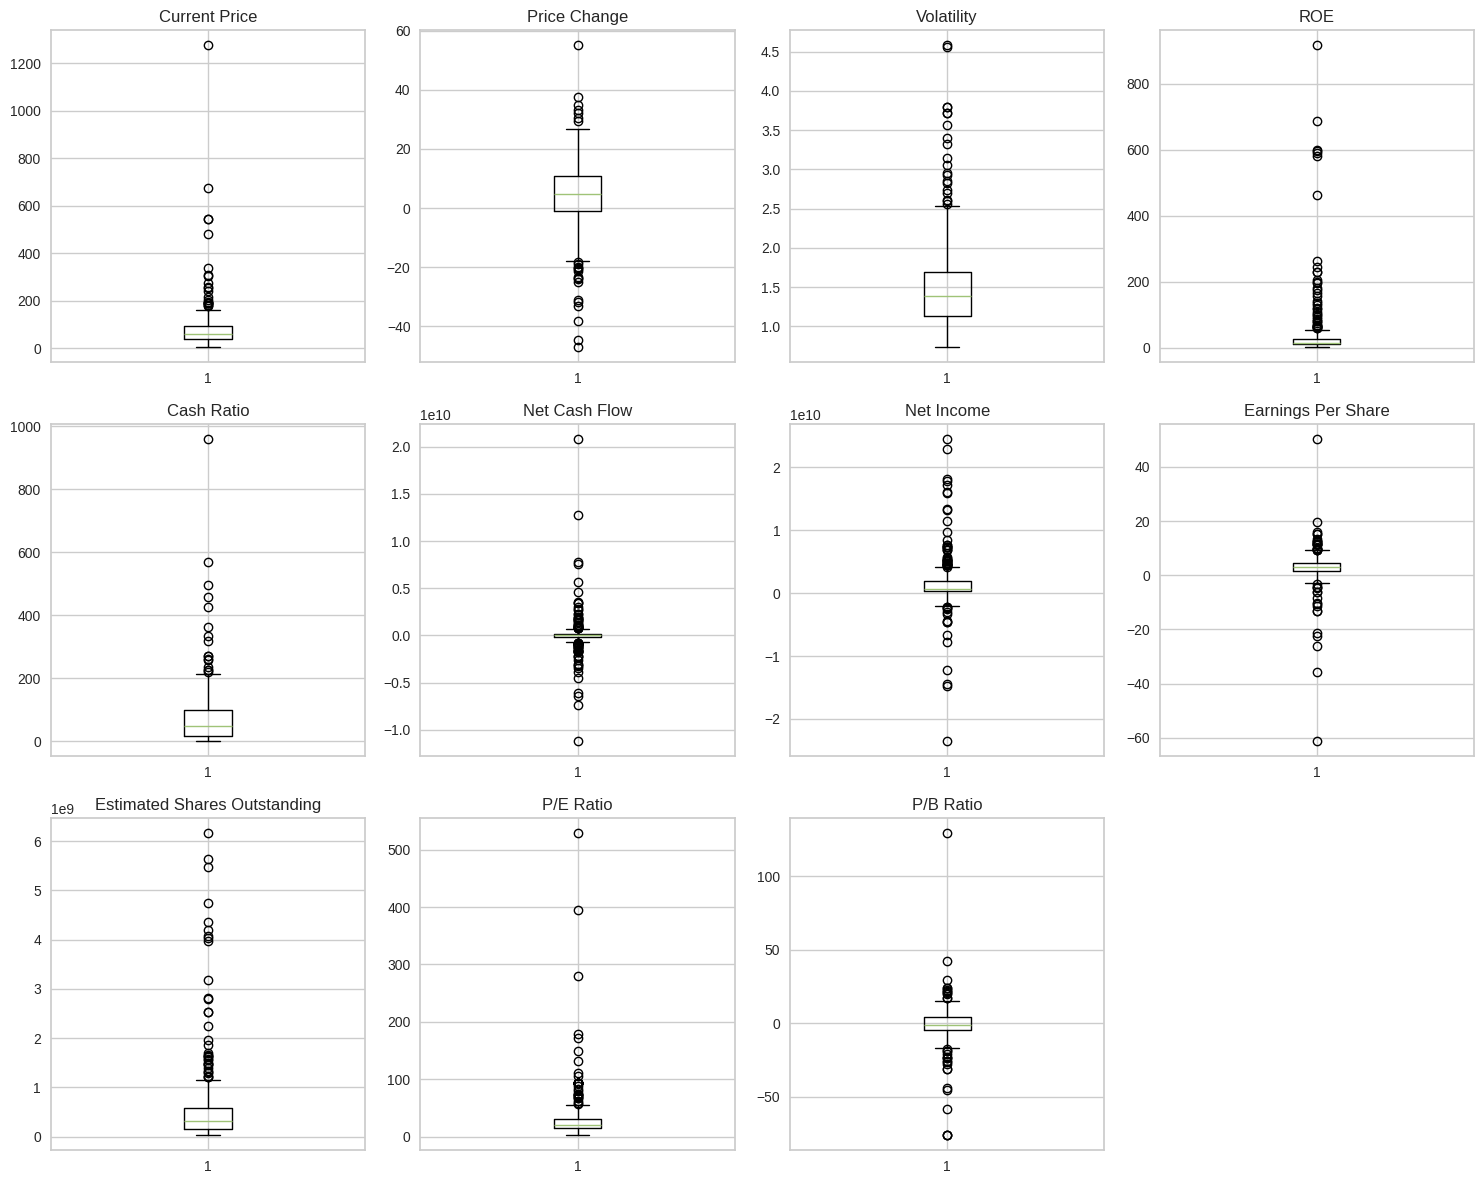

In [28]:
plt.figure(figsize=(15, 12))

numeric_columns_1 = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns_1):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- As mentioned in the EDA, the features in this dataset are positively and/or negatively skewed or heavy-tailed. Since K-Means and Hierarchical Clustering use distance metrics,outliers could dominate or skew clustering algorithms. Subsequently, this can lead to poorly separated clusters.
- However, in Approach 1, we are not treating these outliers (e.g., log) as non-transformed variables will serves as the control for our study—to which we will compare the results of Approach 2: Clustering on Transformed Variables.

### **Scaling**

- We are going to scale the data before we proceed with clustering using StandardScaler.

In [29]:
# selecting numerical features to scale
subset_1 = df.select_dtypes(include=np.number)

# scaling the data before clustering
scaler_1 = StandardScaler()
subset_scaled_1 = scaler_1.fit_transform(subset_1)

In [30]:
# creating a dataframe of the scaled data
subset_scaled_df_1 = pd.DataFrame(subset_scaled_1, columns=subset_1.columns)

In [31]:
# Now subset_scaled_df is your scaled DataFrame, ready for clustering
print(subset_scaled_df_1.head())

   Current Price  Price Change  Volatility   ROE  Cash Ratio  Net Cash Flow  \
0          -0.39          0.49        0.27  0.99       -0.21          -0.34   
1          -0.22          0.36        1.14  0.94        0.08          -0.00   
2          -0.37          0.60       -0.43 -0.19       -0.03           0.45   
3           0.13          0.83       -0.28 -0.32        1.22          -0.15   
4          -0.26         -0.49        0.30 -0.27        2.24           0.13   

   Net Income  Earnings Per Share  Estimated Shares Outstanding  P/E Ratio  \
0        1.55                1.31                          0.11      -0.65   
1        0.93                0.06                          1.25      -0.31   
2        0.74                0.02                          1.10      -0.39   
3       -0.22               -0.23                         -0.09       0.95   
4       -0.20               -0.37                          1.98       3.29   

   P/B Ratio  
0      -0.51  
1      -0.50  
2       0.0

- Now that the features are on the same scale using RobustScaler, we can create our clustering models.

## **K-means Clustering on Transformed Data**

### Finding Optimum k Clusters: Elbow Plot

The Elbow Plot is one of the most commonly used methods for finding the optimal number of clulsters. It is based on plotting cost function values against different values of k. The "elbow point" is the point where the reduction in distortion starts to diminish significantly, marking a trade-off between cluster compactness and the number of clusters.


In [32]:
k_means_df_1 = subset_scaled_df_1.copy()

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.3862098789299604
Number of Clusters: 3 	Average Distortion: 2.33620927590848
Number of Clusters: 4 	Average Distortion: 2.2190505638334423
Number of Clusters: 5 	Average Distortion: 2.133404401901685
Number of Clusters: 6 	Average Distortion: 2.0815036860937144
Number of Clusters: 7 	Average Distortion: 2.0045413402786814
Number of Clusters: 8 	Average Distortion: 1.986423782487441
Number of Clusters: 9 	Average Distortion: 1.956222103389025
Number of Clusters: 10 	Average Distortion: 1.9360473996664198
Number of Clusters: 11 	Average Distortion: 1.8615942883461607
Number of Clusters: 12 	Average Distortion: 1.8219574388532505
Number of Clusters: 13 	Average Distortion: 1.7936924742607907
Number of Clusters: 14 	Average Distortion: 1.7567842179093438


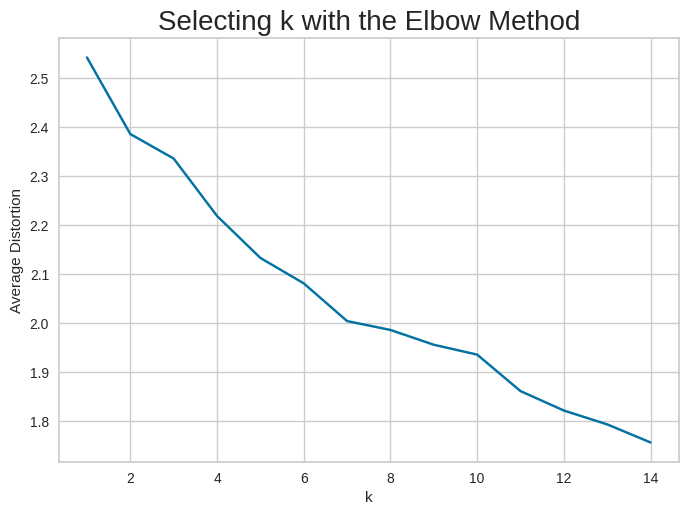

In [33]:
clusters_1 = range(1, 15)
meanDistortions_1 = []

for k in clusters_1:
    model_1 = KMeans(n_clusters=k, random_state=1)
    model_1.fit(subset_scaled_df_1)
    prediction_1 = model_1.predict(k_means_df_1)
    distortion_1 = (
        sum(np.min(cdist(k_means_df_1, model_1.cluster_centers_, "euclidean"), axis=1))
        / k_means_df_1.shape[0]
    )

    meanDistortions_1.append(distortion_1)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion_1)

plt.plot(clusters_1, meanDistortions_1, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

- It is challenging to determine the elbow point where the distortion starts to diminish significantly, so let's use KElbowVisualizer for guidance.

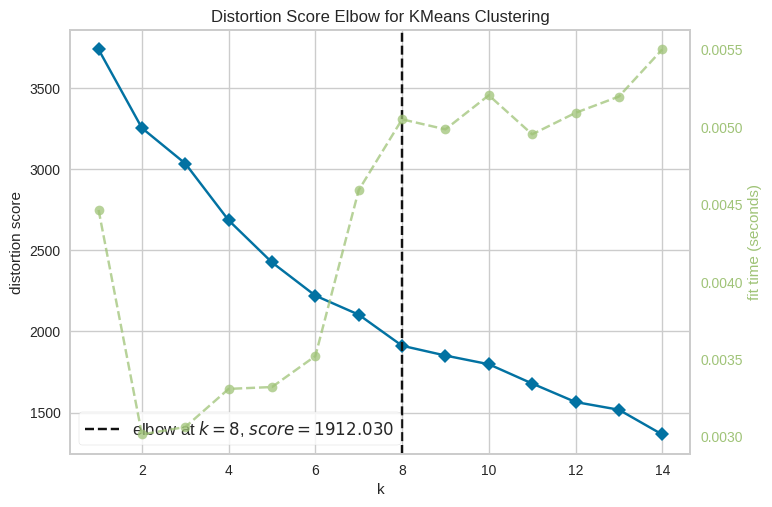

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [34]:
model_1 = KMeans(random_state=1)
visualizer_1 = KElbowVisualizer(model_1, k=(1, 15), timings=True)
visualizer_1.fit(k_means_df_1)  # fit the data to the visualizer
visualizer_1.show()  # finalize and render figure



- Based on the Elow Plot Method, k = 8 seems to be the optimal number of clusters. Let's investigate further using another approach: Silhouette Score.

### Finding Optimum k Clusters: Silhouette Score

Silhouette Score is a metric indicating the effectiveness of a clustering algorithm. It measures how similar points are to each other within a cluster compared to how similar those points are to neighboring clusters.

Its values range from -1 to 1:

* 1 means compact, well-separated clusters
* 0 suggests overalapping, not clearly distinct clusters
* -1 means a data point is closer to the centroid of another cluster of its own (i.e., poor clustering)

For n_clusters = 2, the silhouette score is 0.45335782729503565)
For n_clusters = 3, the silhouette score is 0.40374060030338865)
For n_clusters = 4, the silhouette score is 0.4246430808437099)
For n_clusters = 5, the silhouette score is 0.4381539778147092)
For n_clusters = 6, the silhouette score is 0.40869599703024256)
For n_clusters = 7, the silhouette score is 0.1207450219233897)
For n_clusters = 8, the silhouette score is 0.3693991650696542)
For n_clusters = 9, the silhouette score is 0.35185096182499204)
For n_clusters = 10, the silhouette score is 0.32950073703610283)
For n_clusters = 11, the silhouette score is 0.1486586842527321)
For n_clusters = 12, the silhouette score is 0.15784241071085106)
For n_clusters = 13, the silhouette score is 0.15646997458716602)
For n_clusters = 14, the silhouette score is 0.16253506827999134)


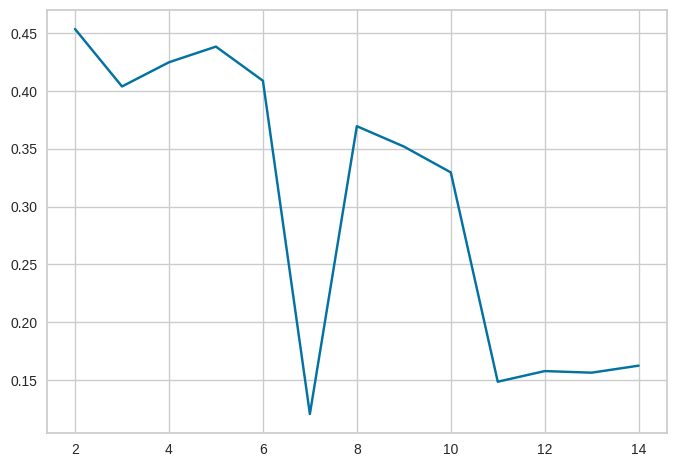

In [35]:
sil_score_1 = []
cluster_list_1 = range(2, 15)
for n_clusters in cluster_list_1:
    clusterer_1 = KMeans(n_clusters=n_clusters, random_state=1)
    preds_1 = clusterer_1.fit_predict((subset_scaled_df_1))
    score_1 = silhouette_score(k_means_df_1, preds_1)
    sil_score_1.append(score_1)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score_1))

plt.plot(cluster_list_1, sil_score_1)
plt.show()

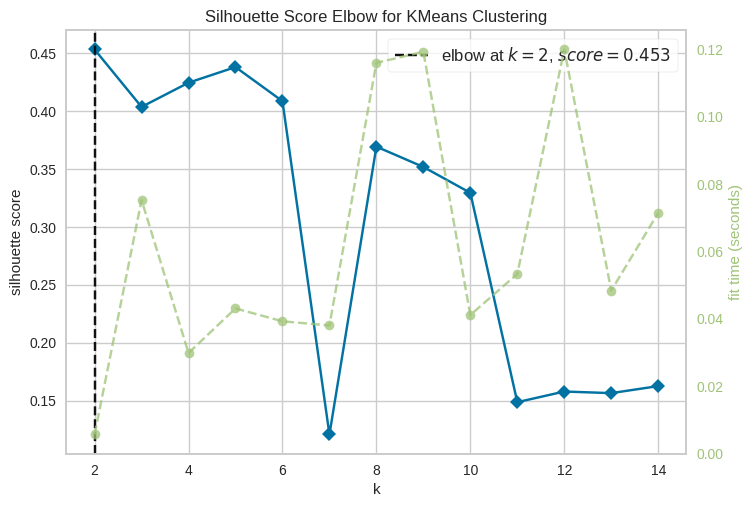

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [36]:
model_1 = KMeans(random_state=1)
visualizer_1 = KElbowVisualizer(model_1, k=(2, 15), metric="silhouette", timings=True)
visualizer_1.fit(k_means_df_1)  # fit the data to the visualizer
visualizer_1.show()  # finalize and render figure

- Based on chart above, the blue line (silhouette score) peaks at k = 2 (0.453), which suggests that the clusters are well separated and internally coherent when split into just two groups.

- Between k = 3 and k = 6, the silhouette scores remain relatively stable (around 0.40–0.43), indicating that these values of k still produce reasonable clusters, but slightly weaker than at k = 2.

- The trough at k = 7 tells us that this partitioning splits natural clusters too much, making it unsuitable.

- The secondary peak at k = 8 to 9 is weaker, but it may represent more granular profiles. However, these clusters risk being less distinct and harder to use for practical recommendations.

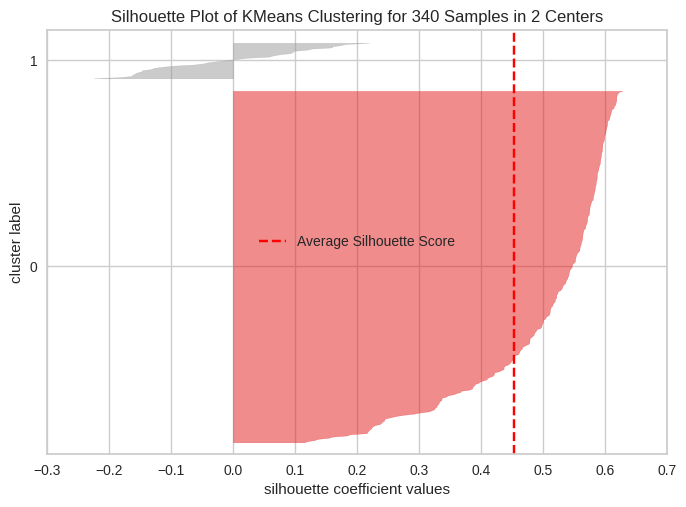

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [37]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_1 = SilhouetteVisualizer(KMeans(n_clusters = 2, random_state=1))
visualizer_1.fit(k_means_df_1)
visualizer_1.show()

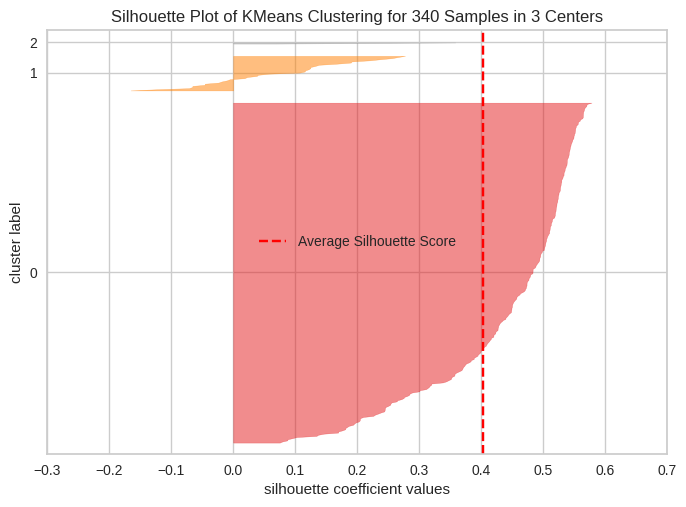

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [38]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_2 = SilhouetteVisualizer(KMeans(n_clusters = 3, random_state=1))
visualizer_2.fit(k_means_df_1)
visualizer_2.show()

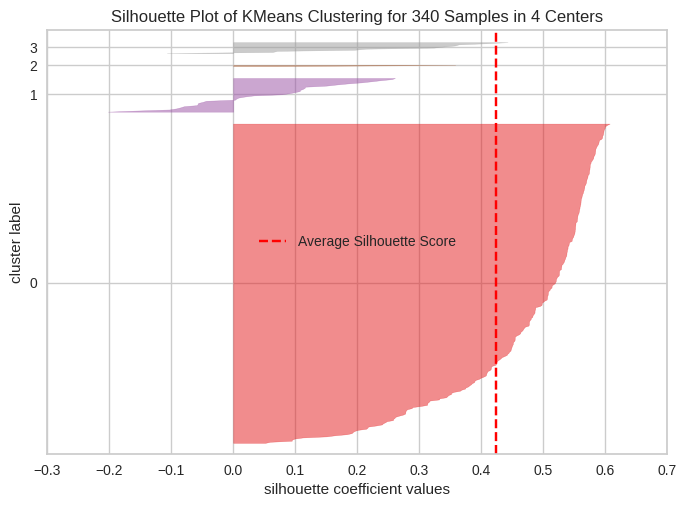

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [39]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_3 = SilhouetteVisualizer(KMeans(n_clusters = 4, random_state=1))
visualizer_3.fit(k_means_df_1)
visualizer_3.show()

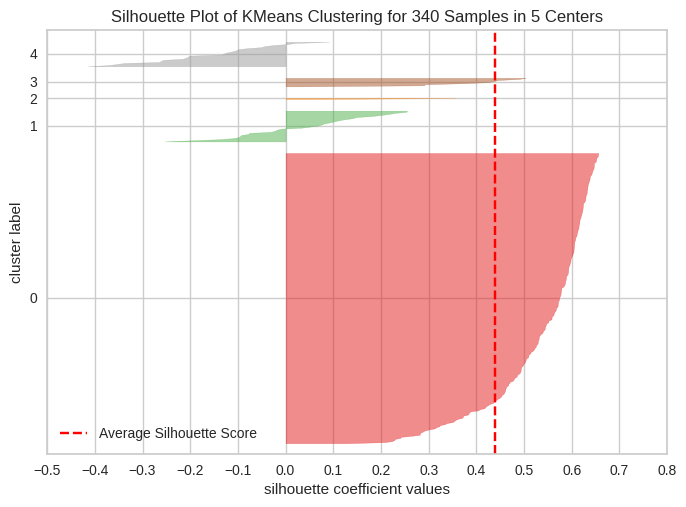

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [40]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_4 = SilhouetteVisualizer(KMeans(n_clusters = 5, random_state=1))
visualizer_4.fit(k_means_df_1)
visualizer_4.show()

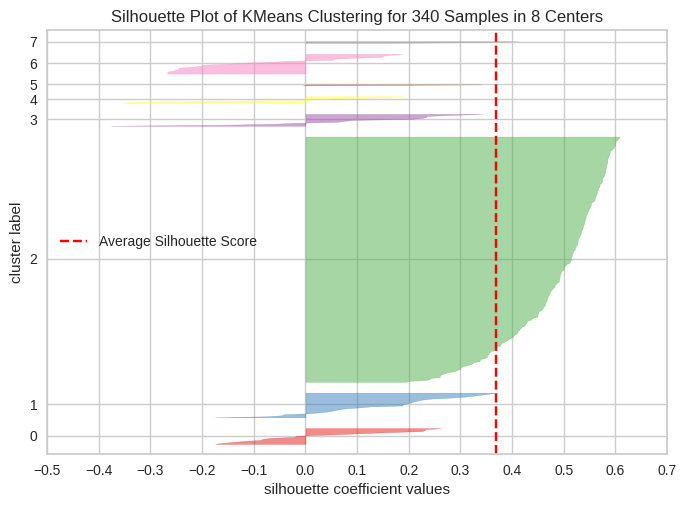

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [41]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_5 = SilhouetteVisualizer(KMeans(n_clusters = 8, random_state=1))
visualizer_5.fit(k_means_df_1)
visualizer_5.show()

- According to the Silhouette Score method, the optimal k is 2, since it maximizes the silhouette score and gives the cleanest cluster separation.

- Even though k = 2 had the highest Silhouette Score (i.e., 0.453), it's still far away from 1, indicating that the clusters are not as effectively separated as the best ideal scenario.

### Chooking k clusters

- The highly varied results of the Elbow Plot and the Silhouette Score poses a major challenge of identifying the right number of pre-defined k for our K-Means Clustering.

- If our goal is to find a broad classification (e.g., separating stocks into two strategic buckets for portfolio allocation, risk vs. defensive), k = 2 is suitable.

- If our use case is segmentation for analysis or screening (e.g., finding similar stocks, building diversified baskets across groups), k = 8 may be more useful despite weaker separation.

- Let's proceed with k = 2 for a broader, well-separated clusters.

### Modeling

In [42]:
# final K-means model
kmeans_1 = KMeans(n_clusters=2, random_state=1)
kmeans_1.fit(k_means_df_1)

KMeans(n_clusters=2, random_state=1)

In [43]:
# creating a copy of the original data
df1_1 = df.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_df_1["KM_segments_1"] = kmeans_1.labels_
df1_1["KM_segments_1"] = kmeans_1.labels_

### Cluster Profiling

In [44]:
km_cluster_profile_1 = df1_1.groupby("KM_segments_1")[subset_1.columns].mean()  ## to groupby the cluster labels

In [45]:
km_cluster_profile_1["count_in_each_segment"] = (
    df1_1.groupby("KM_segments_1")["Security"].count().values  ## to groupby the cluster labels
)

In [46]:
km_cluster_profile_1.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
KM_segments_1,,,,,,,,,,,,
0,82.111257,5.570491,1.394712,31.782468,70.564935,70043230.519481,1986009597.402597,3.889886,584677860.238409,24.668434,-1.778604,308
1,68.841564,-10.285163,2.789397,114.812500,64.812500,-84078875.000000,-3237505968.750000,-7.938125,503401683.841875,109.074811,-1.137335,32


In [47]:
## Complete the code to print the companies in each cluster
for cl in df1_1["KM_segments_1"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1_1[df1_1["KM_segments_1"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Archer-Daniels-Midland Co' 'Alliance Data Systems'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'AutoNation Inc' 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.'
 'Ball Corp' 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'B

In [48]:
df1_1.groupby(["KM_segments_1", "GICS Sector"])['Security'].count()

KM_segments_1  GICS Sector                
0              Consumer Discretionary         37
               Consumer Staples               19
               Energy                          8
               Financials                     49
               Health Care                    39
               Industrials                    52
               Information Technology         29
               Materials                      19
               Real Estate                    27
               Telecommunications Services     5
               Utilities                      24
1              Consumer Discretionary          3
               Energy                         22
               Health Care                     1
               Industrials                     1
               Information Technology          4
               Materials                       1
Name: Security, dtype: int64

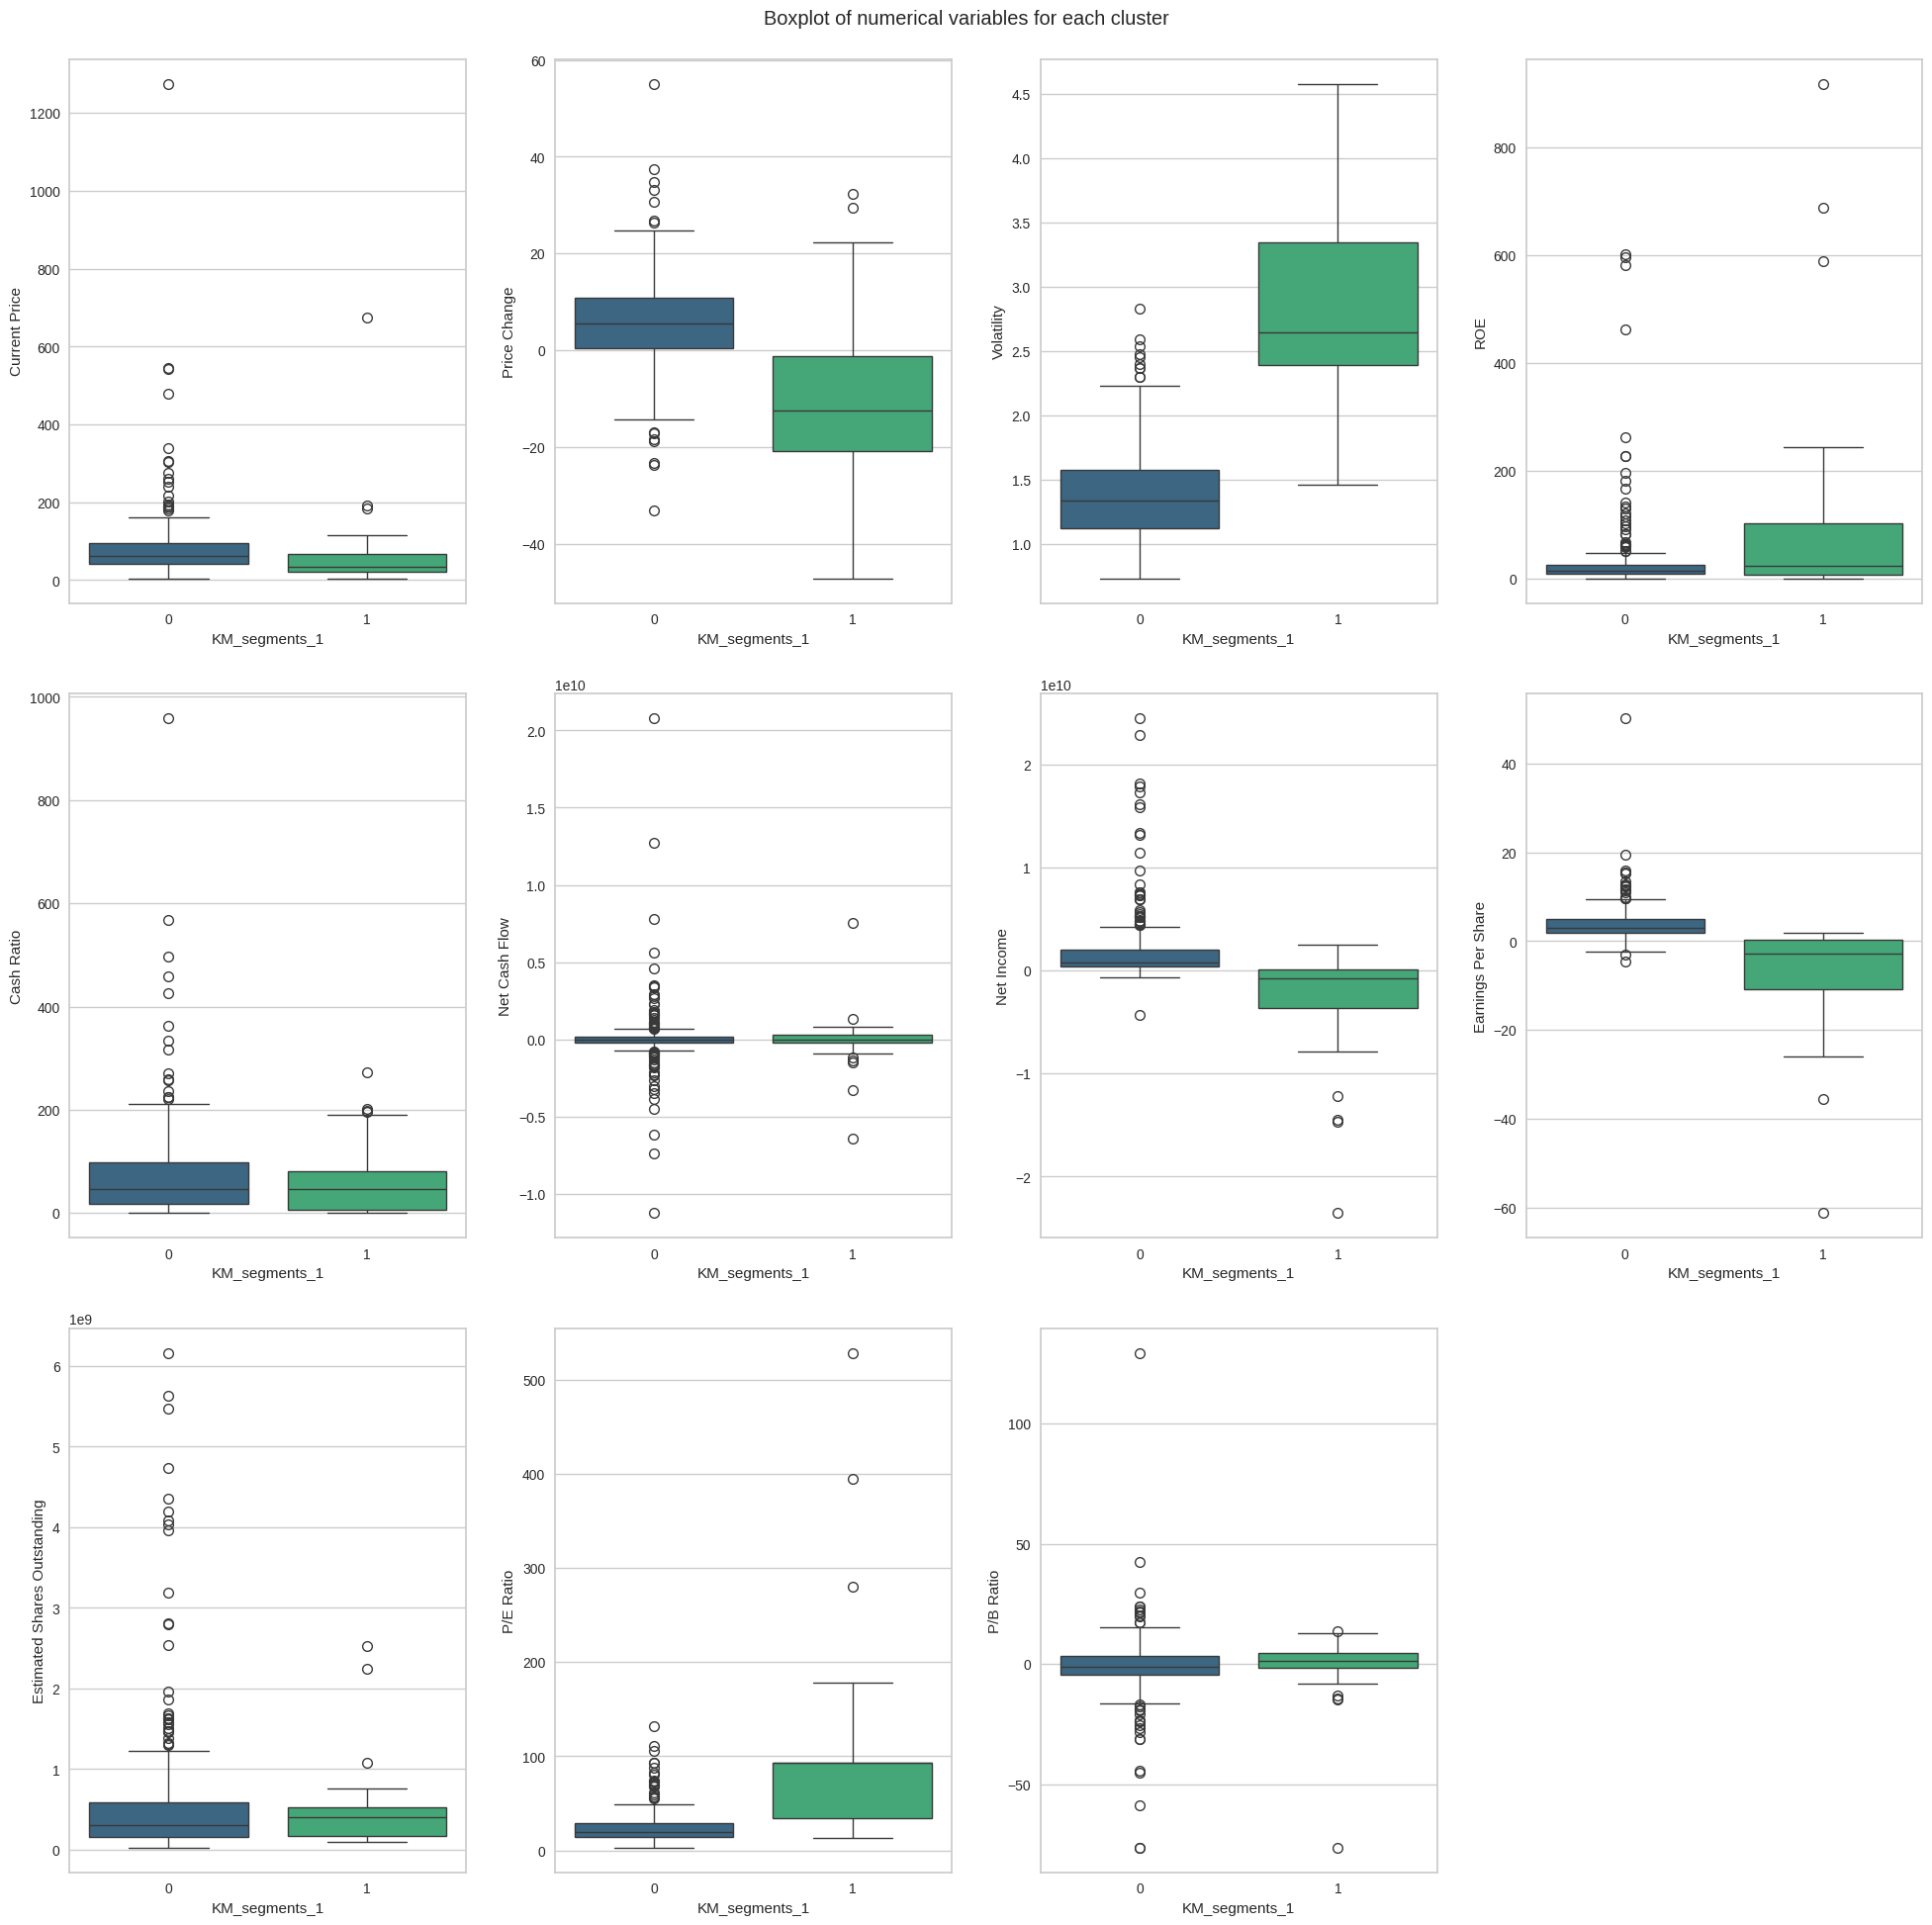

In [49]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

# selecting numerical columns
num_col_1 = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(num_col_1):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1_1, x="KM_segments_1", y=variable, palette='viridis')

plt.tight_layout(pad=2.0)

### Analysis: K Means Clustering on Non-Transformed Variables


- Cluster 0 represents the majority of the market (308 companies). These firms generally show stable financial health, with positive stock price changes, lower volatility, moderate returns on equity, and solid net income. They span across almost all sectors, especially Financials, Industrials, Healthcare, Consumer Discretionary, and IT.

- Cluster 1 contains a smaller group of 32 companies that stand out as distressed or speculative. They have negative stock price performance, very high volatility, negative earnings, and inflated valuation ratios.

- The Energy sector dominates Cluster 1, with 22 of the 32 companies belonging to it. This aligns with the sector’s reputation for being volatile and prone to swings in profitability. A few other outliers from Consumer Discretionary, IT, and Healthcare also fall into this group.

- Overall, the non-transformed data produces a binary split: most companies fall into one large “mainstream” cluster, while a smaller set of distressed and risky firms form the other.




## **Hierarchical Clustering on Non-Transformed Data**

- Hierarchical clustering is a method that builds a hierarchy of clusters, either by merging smaller groups step by step (agglomerative) or splitting a large group step by step (divisive).

- A dendrogram is a tree-like diagram that shows how clusters are combined at different distance thresholds, and cutting it at a chosen level determines the number of clusters.

- Cophenetic correlation measures how well the dendrogram represents the true pairwise distances in the data, with values closer to 1 indicating a better fit.

- This approach is flexible because it can use different distance metrics and linkage methods, making it useful for exploring natural groupings in complex datasets.

### Computing Cophenetic Correlation

In [50]:
hc_df_1 = subset_scaled_df_1.copy()

In [51]:
# list of distance metrics
distance_metrics_1 = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods_1 = ["single", "complete", "average", "weighted"]

high_cophenet_corr_1 = 0
high_dm_lm_1 = [0, 0]

for dm in distance_metrics_1:
    for lm in linkage_methods_1:
        Z_1 = linkage(hc_df_1, metric=dm, method=lm)
        c_1, coph_dists_1 = cophenet(Z_1, pdist(hc_df_1))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c_1
            )
        )
        if high_cophenet_corr_1 < c_1:
            high_cophenet_corr_1 = c_1
            high_dm_lm_1[0] = dm
            high_dm_lm_1[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('='*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr_1, high_dm_lm_1[0].capitalize(), high_dm_lm_1[1]
    )
)

Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7873280186580672.
Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8693784298129404.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9062538164750717.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.598891419111242.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338265528030499.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9127355892367.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.925919553052459.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.7925307202850002.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.9247324030159736.
Cophenetic correla

**Let's explore different linkage methods with Euclidean distance only.**

In [52]:
# list of linkage methods
linkage_methods_1 = ["single", "complete", "average", "centroid", "ward", "weighted"]
high_cophenet_corr_1 = 0
high_dm_lm_1 = [0, 0]

for lm in linkage_methods_1:
    Z_1 = linkage(hc_df_1, metric="euclidean", method=lm)
    c_1, coph_dists_1 = cophenet(Z_1, pdist(hc_df_1))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c_1))
    if high_cophenet_corr_1 < c_1:
        high_cophenet_corr_1 = c_1
        high_dm_lm_1[0] = "euclidean"
        high_dm_lm_1[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('='*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr_1, high_dm_lm_1[1]
    )
)

Cophenetic correlation for single linkage is 0.9232271494002922.
Cophenetic correlation for complete linkage is 0.7873280186580672.
Cophenetic correlation for average linkage is 0.9422540609560814.
Cophenetic correlation for centroid linkage is 0.9314012446828154.
Cophenetic correlation for ward linkage is 0.7101180299865353.
Cophenetic correlation for weighted linkage is 0.8693784298129404.
Highest cophenetic correlation is 0.9422540609560814, which is obtained with average linkage.


**Let's view the dendrograms for the different linkage methods with Euclidean distance.**

### Checking Dendrograms

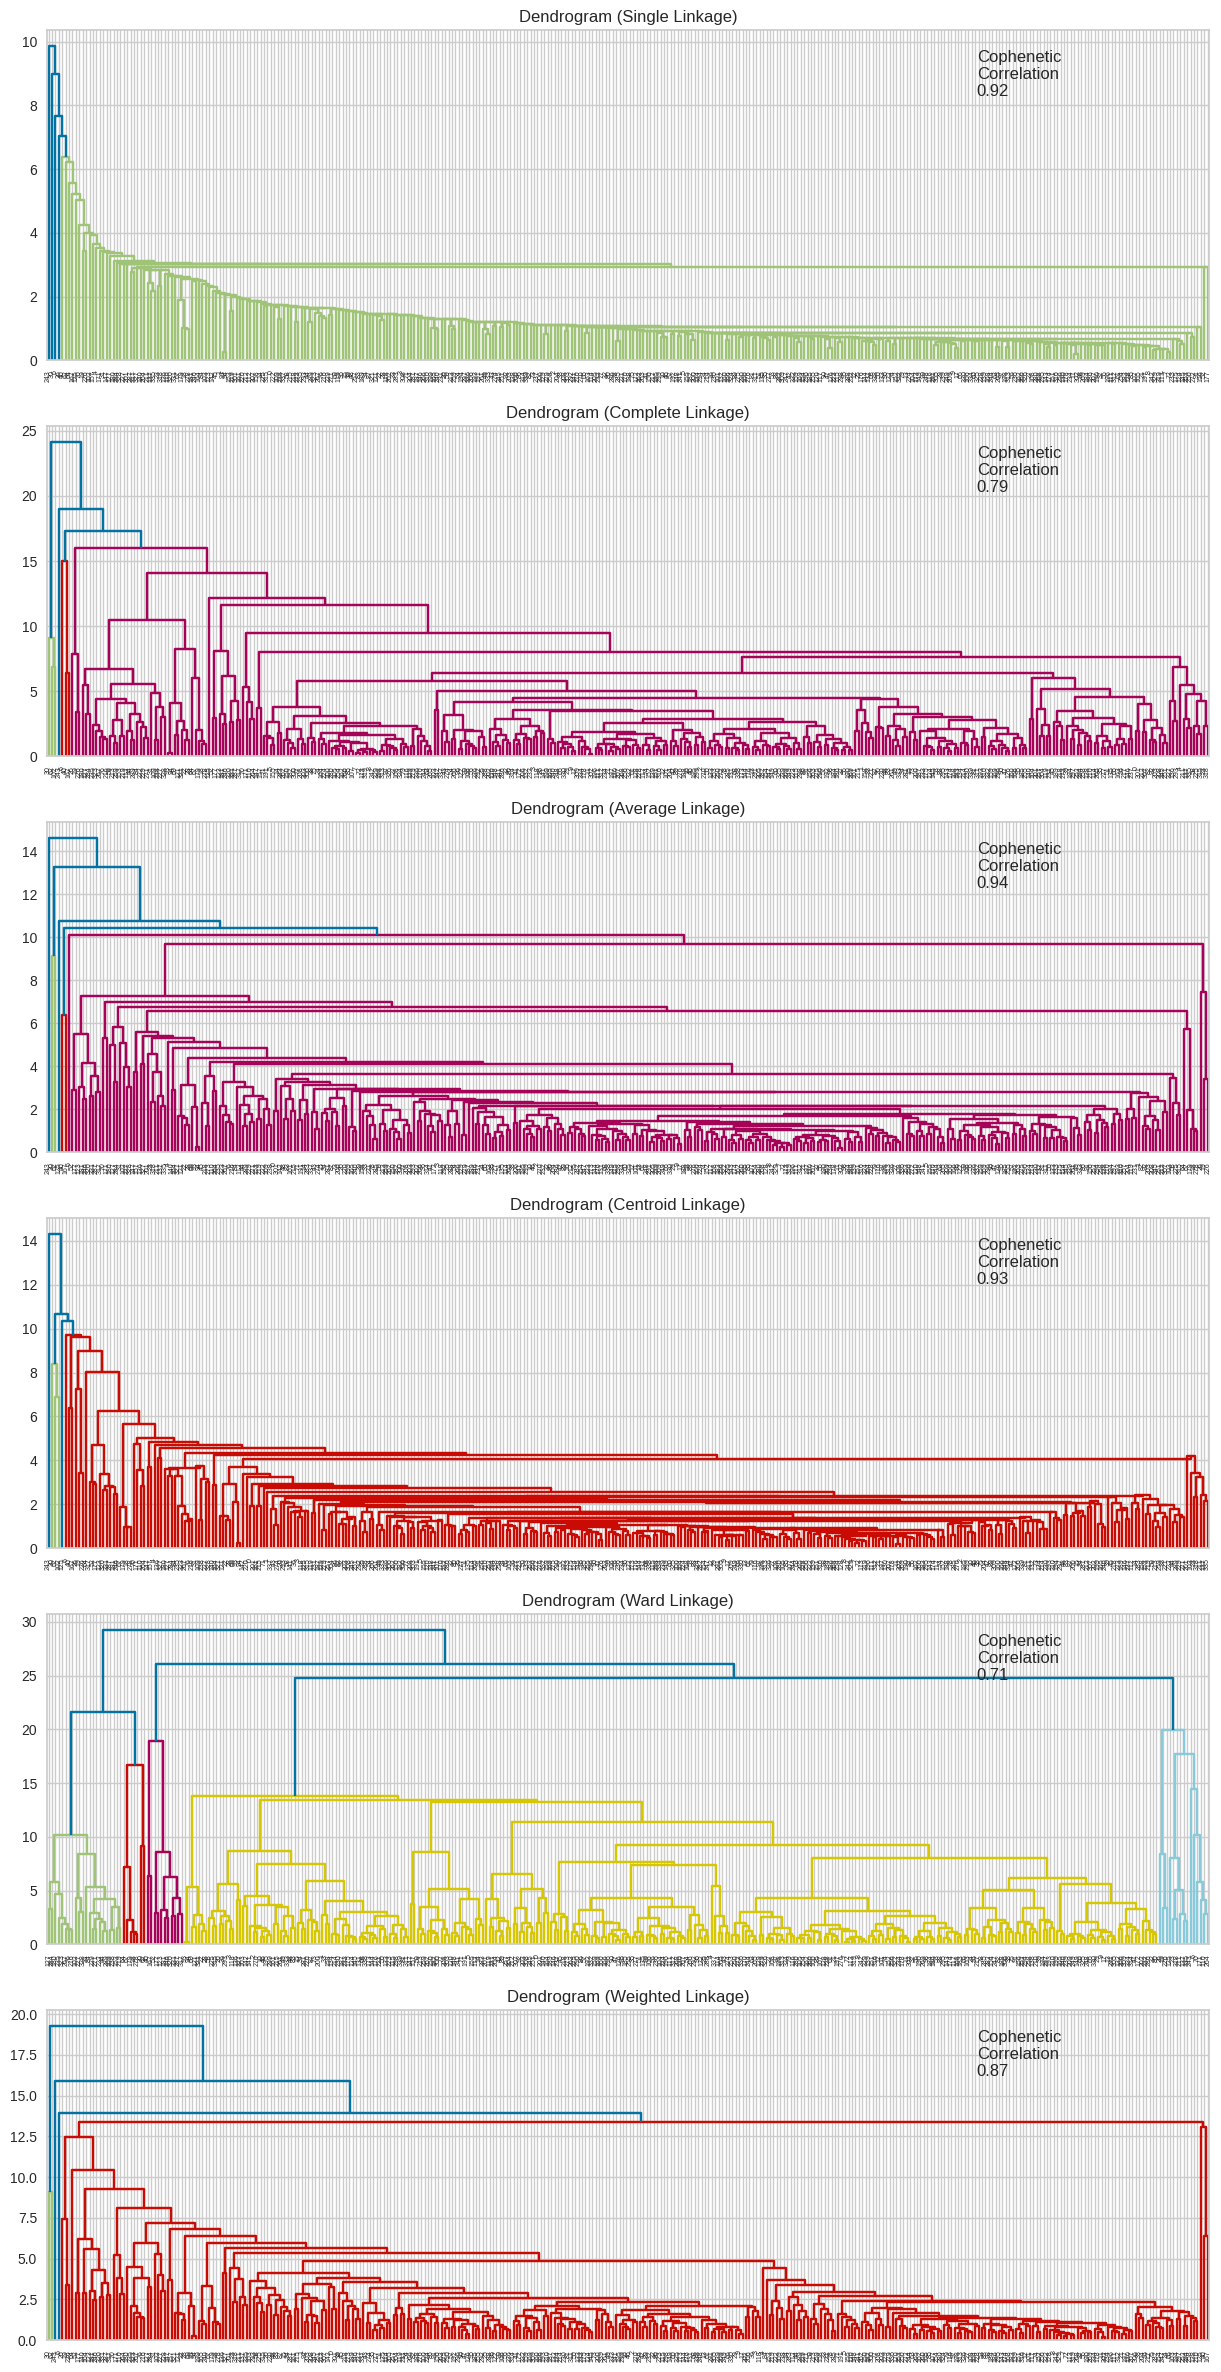

In [53]:
# list of linkage methods
linkage_methods_1 = ["single", "complete", "average", "centroid", "ward", "weighted"] ## Complete the code to add linkages

# lists to save results of cophenetic correlation calculation
compare_cols_1 = ["Linkage", "Cophenetic Coefficient"]
compare_1 = []

# to create a subplot image
fig_1, axs_1 = plt.subplots(len(linkage_methods_1), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods_1):
    Z_1 = linkage(hc_df_1, metric="euclidean", method=method)

    dendrogram(Z_1, ax=axs_1[i])
    axs_1[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr_1, coph_dist_1 = cophenet(Z_1, pdist(hc_df_1))
    axs_1[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr_1:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare_1.append([method, coph_corr_1])

### Choosing k clusters

- Based on the Cophenetic Correlation, using Euclidean distance and average linkage results to the highest cophenetic correlation (0.94).

- From the dendrogram of Euclidean distance and average linkage, our options for k are the following:

  * **k = 2–3** if we cut very high (~12–14), we’d get only broad clusters (mainstream vs outliers).
  * **k = 4** if we cut around ~10–11, we’d obtain a reasonable number of clusters, matching what found in our EDA.
  * **k > 5** (cutting below ~7) produces many fragmented small clusters, which are less interpretable.

- We'll proceed with k = 4 since cutting at ~10–11 clearly splits the dataset into 4 interpretable clusters that are consistent with our EDA findings.

In [54]:
# create and print a dataframe to compare cophenetic correlations for different linkage methods
df_cc_1 = pd.DataFrame(compare_1, columns=compare_cols_1)
df_cc_1 = df_cc_1.sort_values(by="Cophenetic Coefficient")
df_cc_1

,Linkage,Cophenetic Coefficient
4,ward,0.71
1,complete,0.79
5,weighted,0.87
0,single,0.92
3,centroid,0.93
2,average,0.94


### Modeling using sklearn

In [55]:
HCmodel_1 = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
HCmodel_1.fit(subset_scaled_df_1)

AgglomerativeClustering(n_clusters=4)

In [56]:
# creating a copy of the original data
df2_1 = df.copy()

In [57]:
subset_scaled_df_1["HC_Clusters_1"] = HCmodel_1.labels_
df2_1["HC_Clusters_1"] = HCmodel_1.labels_

### Cluster Profiling

In [58]:
# Select only numerical columns for profiling
hc_cluster_profile_1 = df2_1.groupby("HC_Clusters_1")[subset_1.columns].mean()

In [59]:
hc_cluster_profile_1["count_in_each_segment"] = (
    df2_1.groupby("HC_Clusters_1")["Security"].count().values
)

In [60]:
hc_cluster_profile_1.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
HC_Clusters_1,,,,,,,,,,,,
0,48.006208,-11.263107,2.590247,196.551724,40.275862,-495901724.137931,-3597244655.172414,-8.689655,486319827.294483,75.110924,-2.162622,29
1,326.198218,10.563242,1.642560,14.400000,309.466667,288850666.666667,864498533.333333,7.785333,544900261.301333,113.095334,19.142151,15
2,42.848182,6.270446,1.123547,22.727273,71.454545,558636363.636364,14631272727.272728,3.410000,4242572567.290909,15.242169,-4.924615,11
3,72.760400,5.213307,1.427078,25.603509,60.392982,79951512.280702,1538594322.807018,3.655351,446472132.228456,24.722670,-2.647194,285


In [61]:
## Printing the companies in each cluster
for cl in df2_1["HC_Clusters_1"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2_1[df2_1["HC_Clusters_1"] == cl]["Security"].unique())
    print()

In cluster 3, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Ameriprise Financial' 'American Tower Corp A' 'AutoNation Inc'
 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.' 'Ball Corp'
 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'Boston Properties' 'Caterpillar Inc.' 'Chubb Lim

In [62]:
df2_1.groupby(["HC_Clusters_1", "GICS Sector"])['Security'].count()

HC_Clusters_1  GICS Sector                
0              Consumer Discretionary          1
               Consumer Staples                2
               Energy                         22
               Financials                      1
               Industrials                     1
               Information Technology          1
               Materials                       1
1              Consumer Discretionary          3
               Consumer Staples                1
               Health Care                     5
               Information Technology          4
               Real Estate                     1
               Telecommunications Services     1
2              Consumer Discretionary          1
               Consumer Staples                1
               Energy                          1
               Financials                      4
               Health Care                     1
               Information Technology          1
               Telecommunications Services     2
3              Consumer Discretionary         35
               Consumer Staples               15
               Energy                          7
               Financials                     44
               Health Care                    34
               Industrials                    52
               Information Technology         27
               Materials                      19
               Real Estate                    26
               Telecommunications Services     2
               Utilities                      24
Name: Security, dtype: int64

### Analysis: Hierarchical Clustering on Non-Transformed Variables

* **Cluster 0 (29 companies)** groups mostly distressed Energy firms, along with a few scattered companies from Consumer Staples, Financials, Industrials, and IT. These firms stand out for negative stock price changes, very high volatility, and strongly negative earnings. Energy dominates this cluster with 22 of the 29 companies, showing that the sector’s instability heavily drives its own grouping.

* **Cluster 1 (15 companies)** contains a small mix of Consumer, Healthcare, and IT firms, along with a few from other sectors. Financially, these companies have very high stock prices, extremely high liquidity (cash ratio over 300), and unusually high P/E and P/B ratios. This cluster represents firms that are speculative in nature, with investors pricing them far above their fundamentals.

* **Cluster 2 (11 companies)** includes mostly Financials and a handful of others. These companies are highly profitable with strong net income and positive cash flows, but they also have distorted valuations, such as negative book values (negative P/B). They appear to be “cash-rich large caps” that are unusual compared to the broader market.

* **Cluster 3 (285 companies)** represents the mainstream of the market, covering all major sectors such as Financials, Industrials, Healthcare, and IT. These firms are financially stable, with moderate profitability, positive returns, and valuations that sit closer to typical levels.

* Overall, the non-transformed data makes the clustering **heavily sector-driven**, especially with Energy forming its own outlier cluster. Compared to the transformed version, which separated firms by financial traits like growth, liquidity, and distorted fundamentals, the non-transformed results emphasize large sector-based differences and extreme outliers.

# **8. Approach 2: Clustering on Transformed Features**

## **Data Pre-processing**

Data pre-processing may include the following processes depending on the need:
- Missing value treatment
- Outlier detection and treatment
- Feature engineering
- Preparing data for modeling
- Any other preprocessing steps

### **Outlier Detection and Treatment**


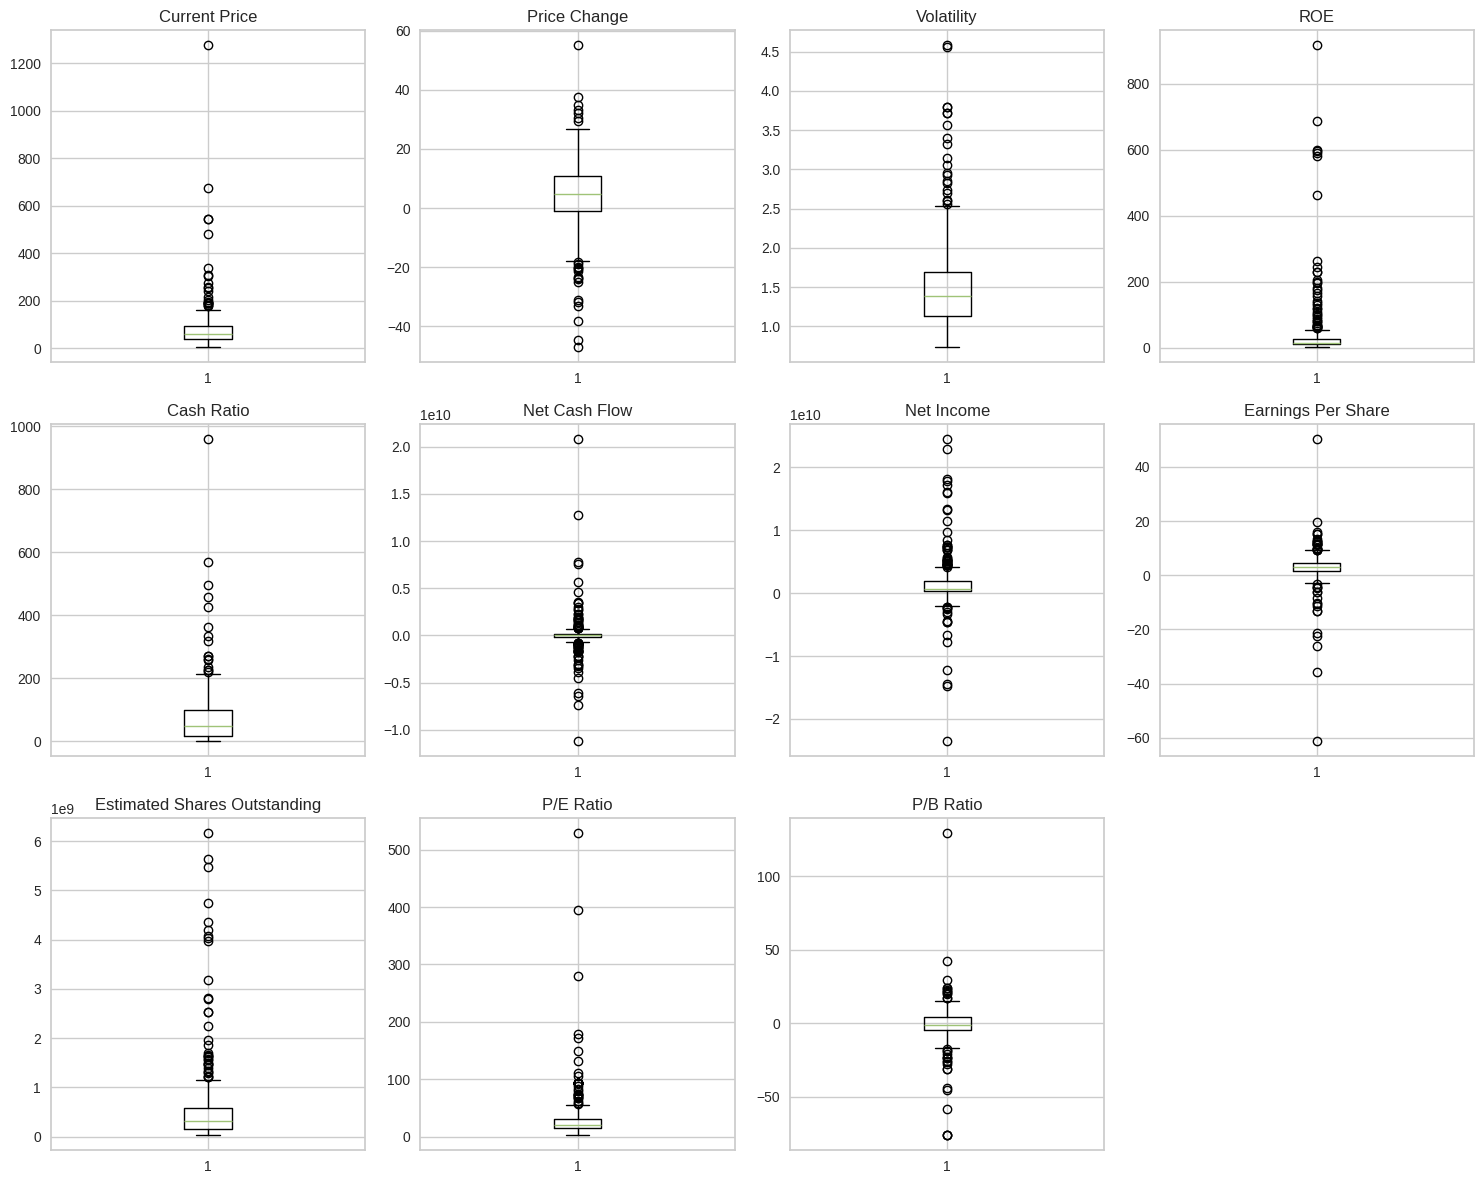

In [63]:
plt.figure(figsize=(15, 12))

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### **Feature Transformations & Scaling using Pipeline**

In [64]:
import numpy as np
from sklearn.preprocessing import PowerTransformer, FunctionTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import set_config

set_config(transform_output="pandas")

# 11 numeric features
log1p_cols = [  # non-negative
    "Current Price",
    "Estimated Shares Outstanding",
    "Volatility",
    "Cash Ratio",
]
yj_cols = [     # can be negative / heavy-tailed
    "Net Income",
    "Net Cash Flow",
    "Earnings Per Share",
    "Price Change",
    "P/B Ratio",
    "ROE",
    "P/E Ratio",
]
numeric_cols = log1p_cols + yj_cols

# numeric branch: transform & then scale
numeric_branch = Pipeline([
    ("transform", ColumnTransformer(
        transformers=[
            ("log1p", FunctionTransformer(np.log1p, validate=False,
                                          feature_names_out="one-to-one"), log1p_cols),
            ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False), yj_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )),
    ("scale", StandardScaler())
])

# full preprocessor: numeric (processed) + IDs (passthrough)
preproc = ColumnTransformer(
    transformers=[
        ("num", numeric_branch, numeric_cols),
    ],
    remainder="drop", # in case there are unwanted columns
    verbose_feature_names_out=False
)

# fit/transform
subset_scaled_df_2 = preproc.fit_transform(df)              # scaled numerics

print(subset_scaled_df_2.head())


   Current Price  Estimated Shares Outstanding  Volatility  Cash Ratio  \
0          -0.45                          0.71        0.42        0.24   
1          -0.01                          1.62        1.28        0.58   
2          -0.38                          1.54       -0.41        0.46   
3           0.61                          0.41       -0.23        1.27   
4          -0.10                          1.94        0.44        1.61   

   Net Income  Net Cash Flow  Earnings Per Share  Price Change  P/B Ratio  \
0        1.69          -0.34                1.60          0.46      -0.51   
1        0.99           0.07               -0.02          0.30      -0.50   
2        0.78           0.46               -0.06          0.59       0.10   
3       -0.29          -0.11               -0.35          0.85       0.43   
4       -0.27           0.19               -0.50         -0.59       0.20   

    ROE  P/E Ratio  
0  1.76      -3.56  
1  1.74      -0.23  
2  0.30      -0.58  
3 -0.60 

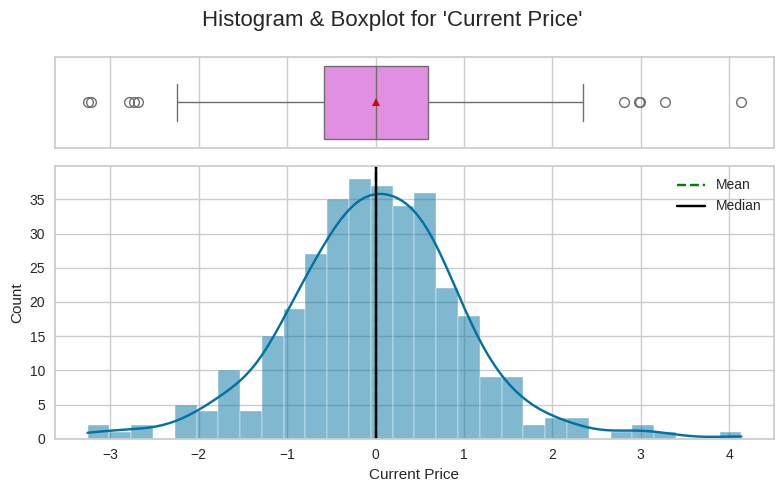

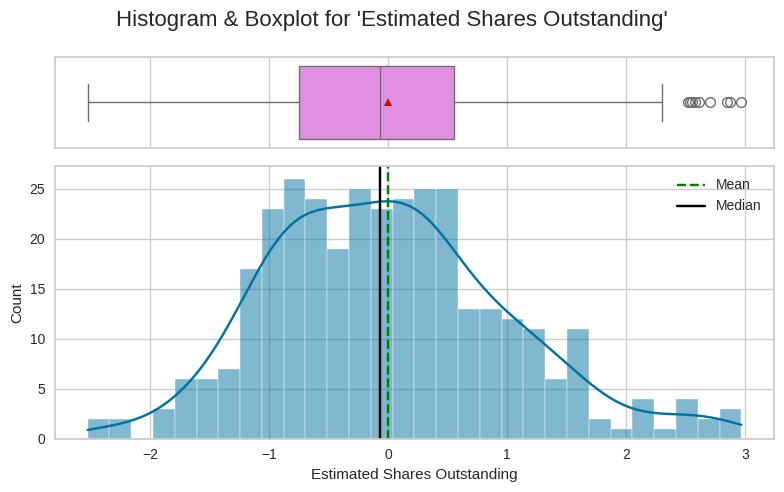

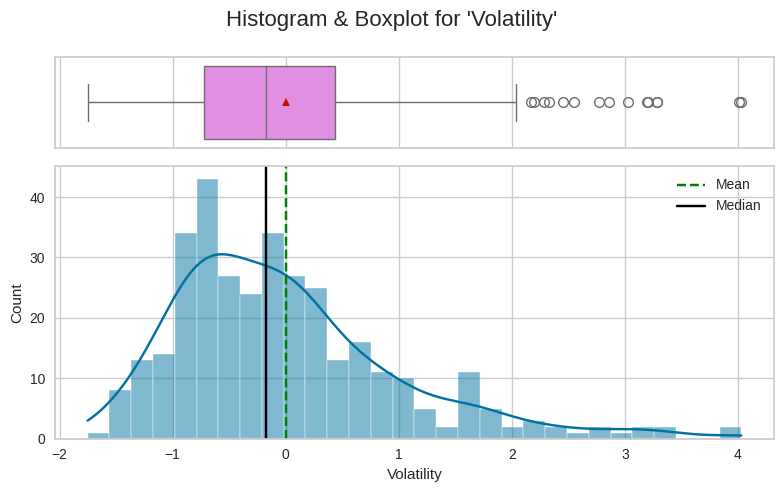

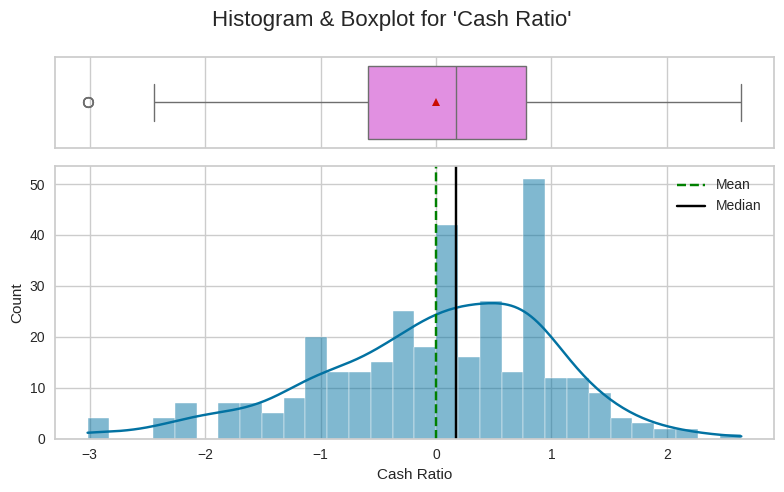

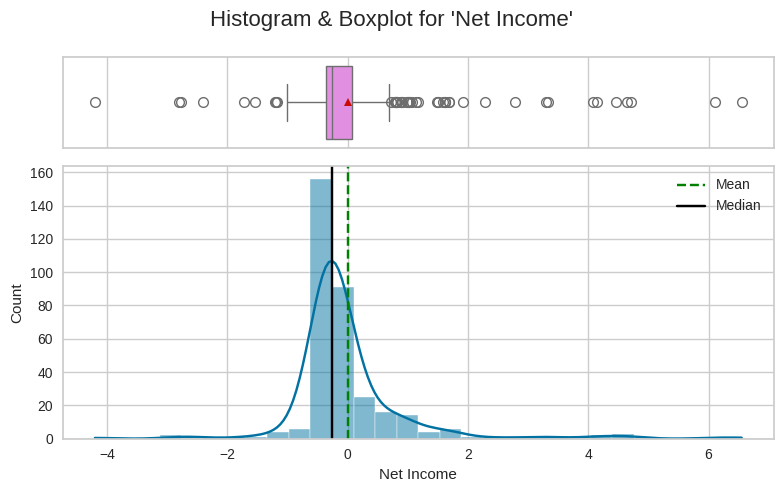

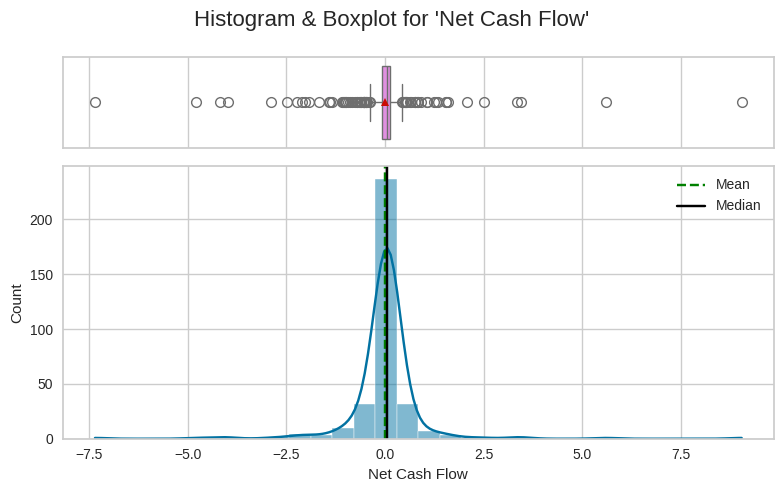

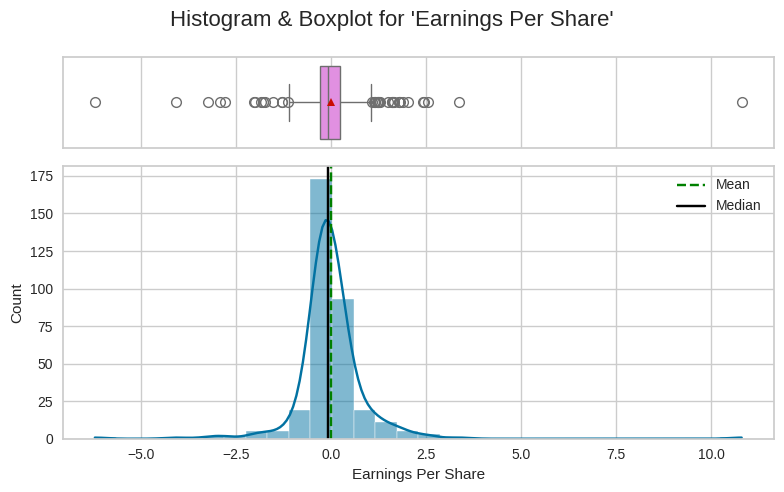

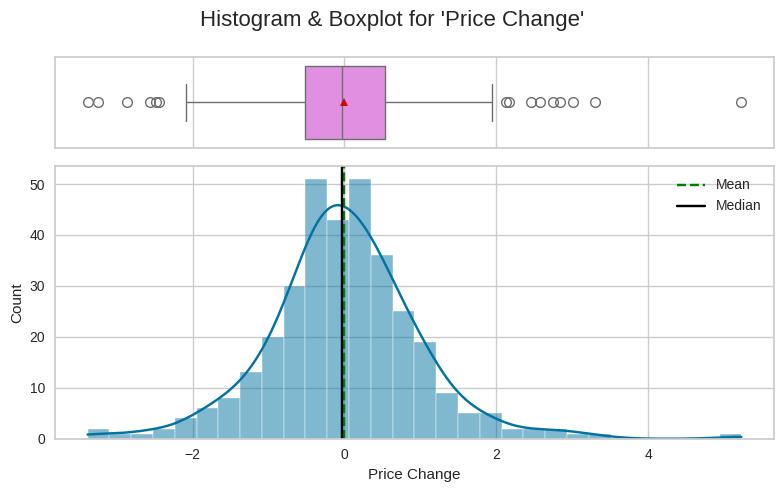

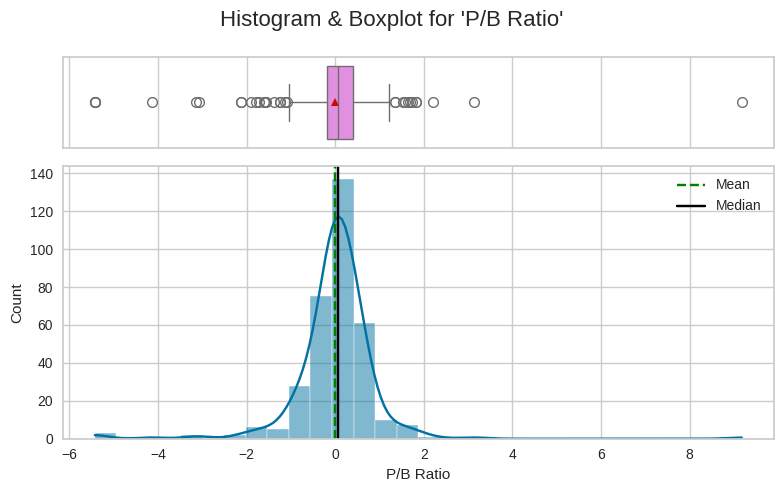

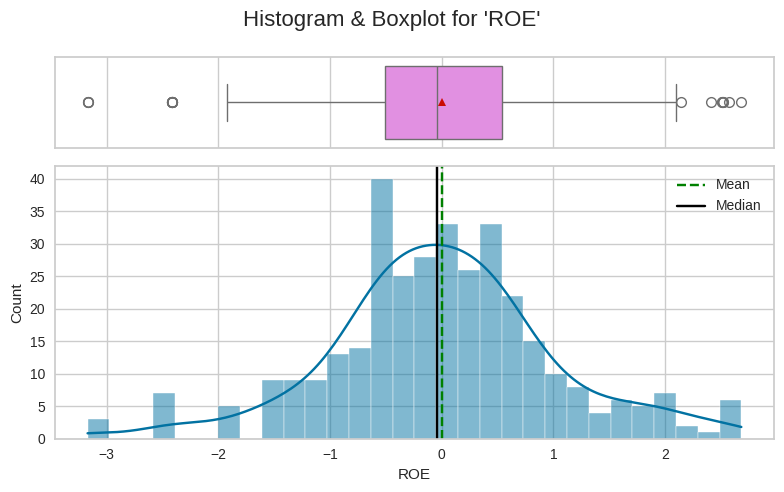

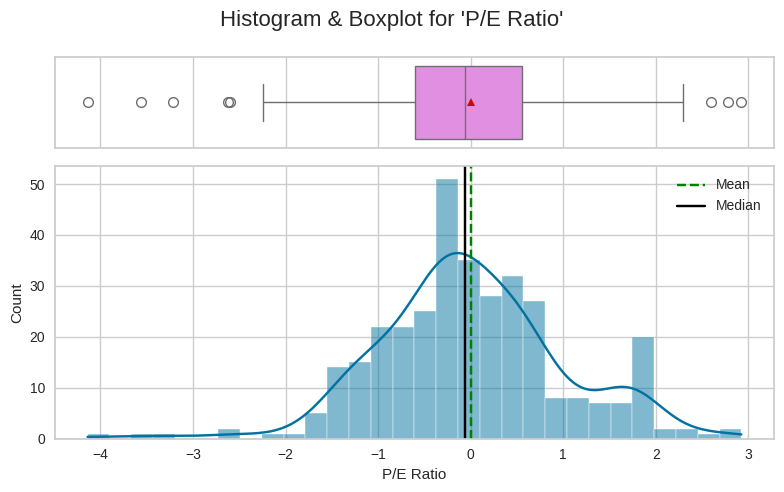

In [65]:
auto_histogram_boxplot(subset_scaled_df_2, kde=True, bins=30)

In [66]:
subset_scaled_df_2.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.00,-0.00,1.00,-3.26,-0.58,0.00,0.60,4.14
Estimated Shares Outstanding,340.00,-0.00,1.00,-2.53,-0.75,-0.07,0.55,2.97
Volatility,340.00,-0.00,1.00,-1.75,-0.72,-0.17,0.43,4.03
Cash Ratio,340.00,0.00,1.00,-3.02,-0.59,0.17,0.78,2.65
Net Income,340.00,0.00,1.00,-4.20,-0.36,-0.27,0.07,6.55
Net Cash Flow,340.00,-0.00,1.00,-7.35,-0.08,0.05,0.12,9.03
Earnings Per Share,340.00,0.00,1.00,-6.21,-0.30,-0.07,0.25,10.80
Price Change,340.00,-0.00,1.00,-3.38,-0.52,-0.03,0.53,5.23
P/B Ratio,340.00,0.00,1.00,-5.42,-0.18,0.05,0.41,9.17
ROE,340.00,0.00,1.00,-3.17,-0.51,-0.04,0.54,2.68


- All features are standardized with mean ≈ 0 and std ≈ 1, confirming that the scaling worked correctly.

- Most variables are now centered around zero, and skewness has been reduced by the log and Yeo–Johnson transformations.

- Some features (like Earnings Per Share, Net Cash Flow, and P/B Ratio) still show higher positive outliers, but this is expected in financial data.

- Overall, the data is now well-prepared for clustering, with transformations reducing skewness and scaling ensuring fairness across features.

## **K-means Clustering on Transformed Data**

### Finding Optimum k Clusters: Elbow Plot

In [67]:
k_means_df_2 = subset_scaled_df_2.copy()

Number of Clusters: 1 	Average Distortion: 2.9293829994804903
Number of Clusters: 2 	Average Distortion: 2.790615906419163
Number of Clusters: 3 	Average Distortion: 2.6859630255034315
Number of Clusters: 4 	Average Distortion: 2.572889677136725
Number of Clusters: 5 	Average Distortion: 2.4703452304993307
Number of Clusters: 6 	Average Distortion: 2.4133764740013772
Number of Clusters: 7 	Average Distortion: 2.345887967709926
Number of Clusters: 8 	Average Distortion: 2.3151576916946377
Number of Clusters: 9 	Average Distortion: 2.2780354814734585
Number of Clusters: 10 	Average Distortion: 2.236682313689714
Number of Clusters: 11 	Average Distortion: 2.2040534807943026
Number of Clusters: 12 	Average Distortion: 2.15402780000519
Number of Clusters: 13 	Average Distortion: 2.112092191417431
Number of Clusters: 14 	Average Distortion: 2.0638136664461424


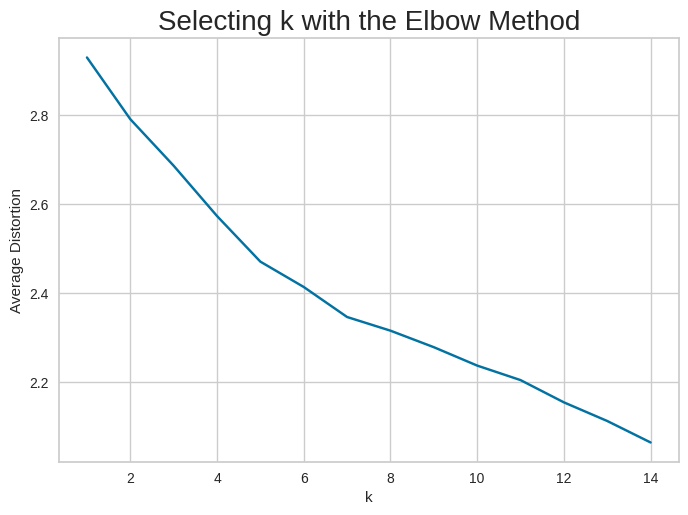

In [68]:
clusters_2 = range(1, 15)
meanDistortions_2 = []

for k in clusters_2:
    model_2 = KMeans(n_clusters=k, random_state=1)
    model_2.fit(subset_scaled_df_2)
    prediction_2 = model_2.predict(k_means_df_2)
    distortion_2 = (
        sum(np.min(cdist(k_means_df_2, model_2.cluster_centers_, "euclidean"), axis=1))
        / k_means_df_2.shape[0]
    )

    meanDistortions_2.append(distortion_2)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion_2)

plt.plot(clusters_2, meanDistortions_2, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

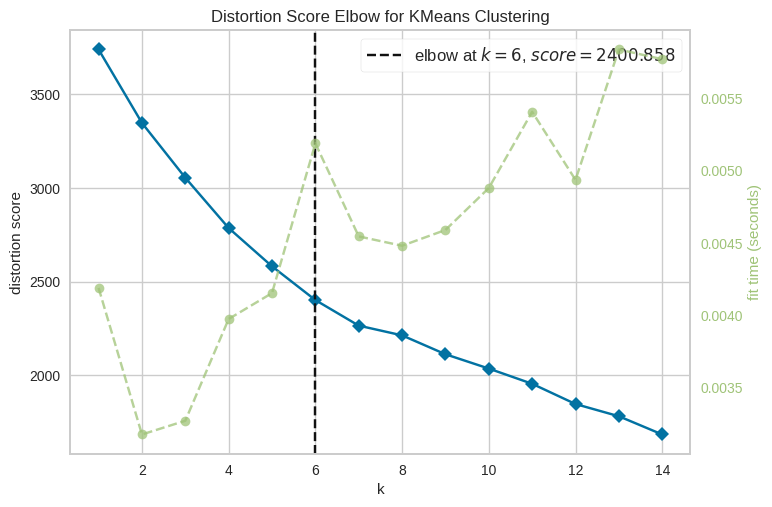

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [69]:
model_2 = KMeans(random_state=1)
visualizer_2 = KElbowVisualizer(model_2, k=(1, 15), timings=True)
visualizer_2.fit(k_means_df_2)  # fit the data to the visualizer
visualizer_2.show()  # finalize and render figure

### Finding Optimum k Clusters: Silhouette Score

For n_clusters = 2, the silhouette score is 0.2022074735392066)
For n_clusters = 3, the silhouette score is 0.18427540357903435)
For n_clusters = 4, the silhouette score is 0.1275271651353797)
For n_clusters = 5, the silhouette score is 0.10378107887517345)
For n_clusters = 6, the silhouette score is 0.11440154669537586)
For n_clusters = 7, the silhouette score is 0.10359252767034285)
For n_clusters = 8, the silhouette score is 0.10578366725097031)
For n_clusters = 9, the silhouette score is 0.10211039150319265)
For n_clusters = 10, the silhouette score is 0.10569465820527346)
For n_clusters = 11, the silhouette score is 0.10912417030460779)
For n_clusters = 12, the silhouette score is 0.11694808108654821)
For n_clusters = 13, the silhouette score is 0.10686460384909947)
For n_clusters = 14, the silhouette score is 0.11507948551343142)


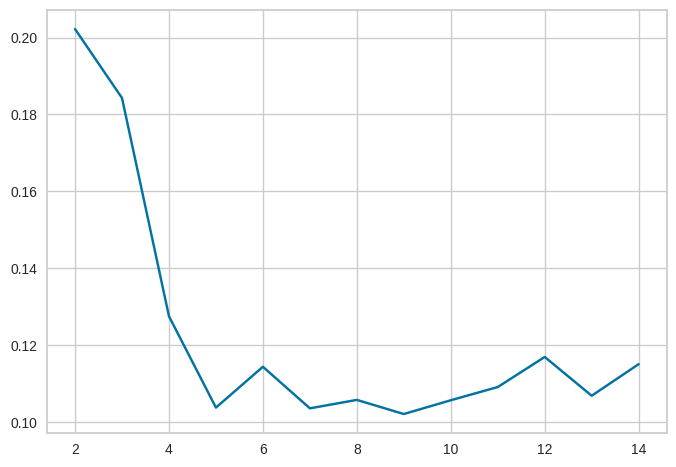

In [70]:
sil_score_2 = []
cluster_list_2 = range(2, 15)
for n_clusters in cluster_list_2:
    clusterer_2 = KMeans(n_clusters=n_clusters, random_state=1)
    preds_2 = clusterer_2.fit_predict((subset_scaled_df_2))
    score_2 = silhouette_score(k_means_df_2, preds_2)
    sil_score_2.append(score_2)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score_2))

plt.plot(cluster_list_2, sil_score_2)
plt.show()

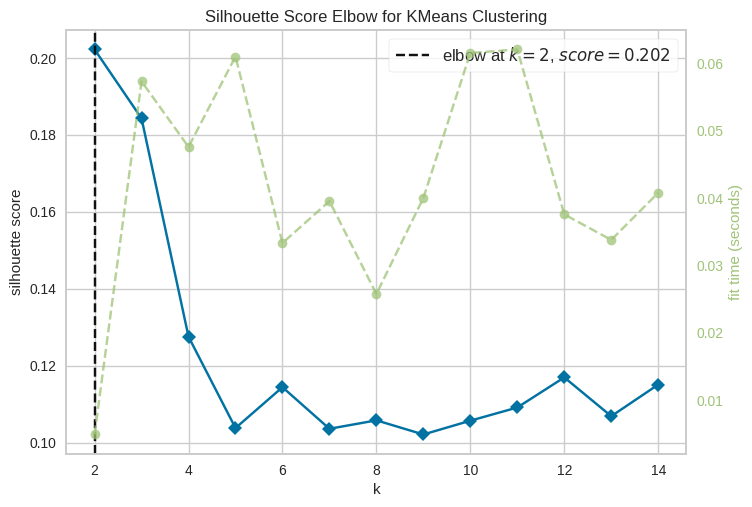

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [71]:
model_2 = KMeans(random_state=1)
visualizer_2 = KElbowVisualizer(model_2, k=(2, 15), metric="silhouette", timings=True)
visualizer_2.fit(k_means_df_2)  # fit the data to the visualizer
visualizer_2.show()  # finalize and render figure

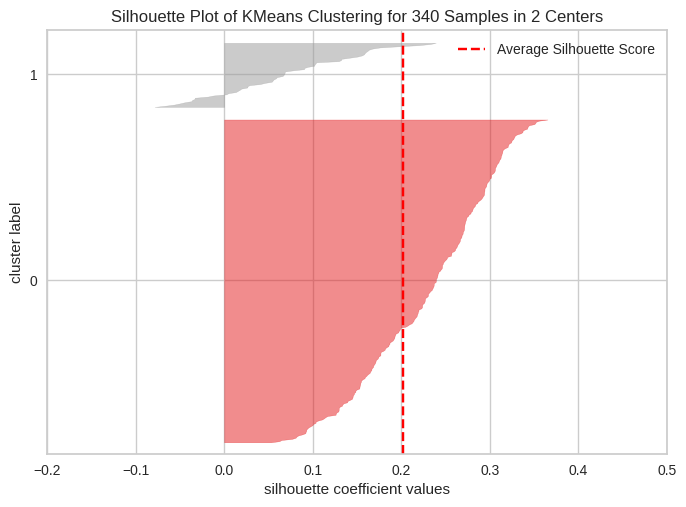

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [72]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_2 = SilhouetteVisualizer(KMeans(n_clusters = 2, random_state=1))
visualizer_2.fit(k_means_df_2)
visualizer_2.show()

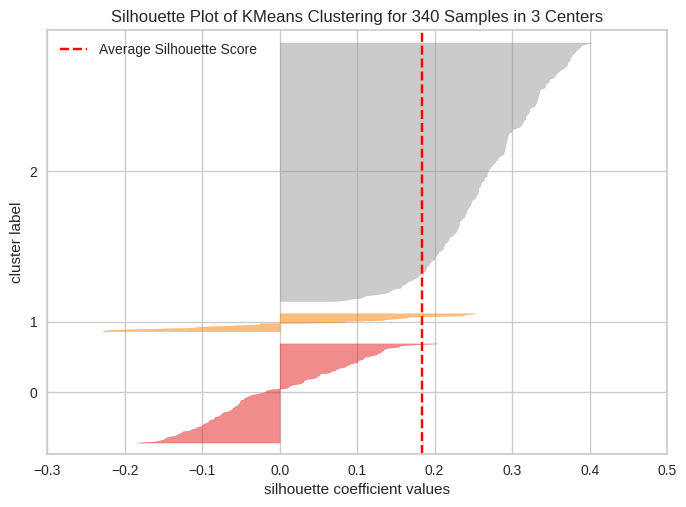

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [73]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_2 = SilhouetteVisualizer(KMeans(n_clusters = 3, random_state=1))
visualizer_2.fit(k_means_df_2)
visualizer_2.show()

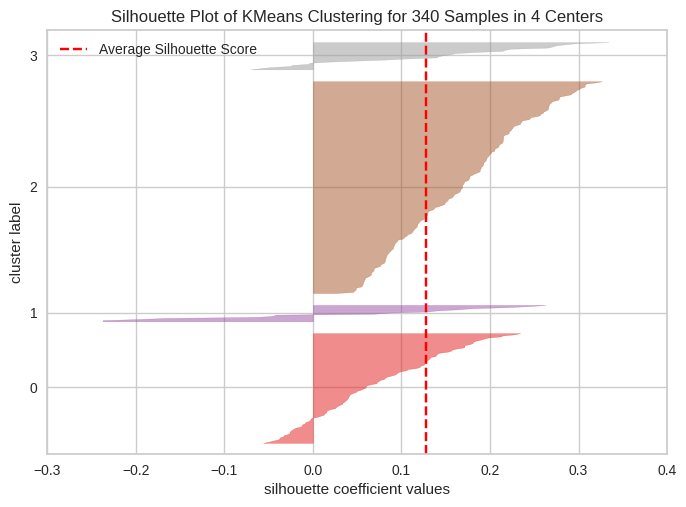

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [74]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_2 = SilhouetteVisualizer(KMeans(n_clusters = 4, random_state=1))
visualizer_2.fit(k_means_df_2)
visualizer_2.show()

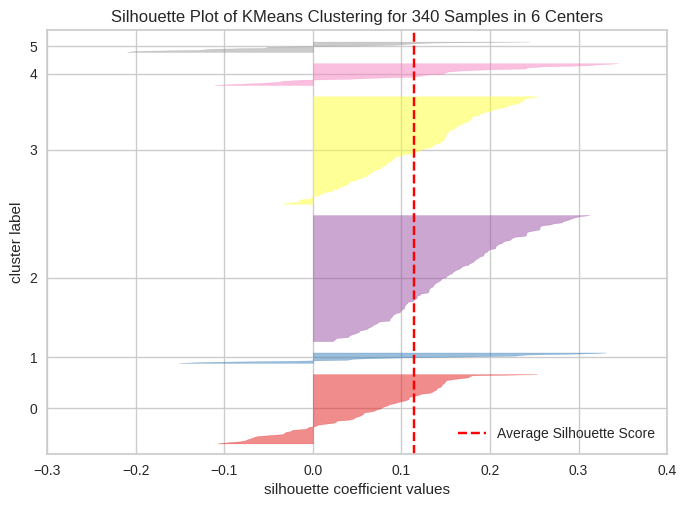

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [75]:
# finding optimal no. of clusters with silhouette coefficients
visualizer_2 = SilhouetteVisualizer(KMeans(n_clusters = 6, random_state=1))
visualizer_2.fit(k_means_df_2)
visualizer_2.show()

### Chooking k clusters

- Similar to the challenge encountered earlier, it is unclear which number of clusters is the most appropriate.

- It should also be noted that the Silhouette Scores are poor with peak at 0.202 (way less than 1).

- The Elbow method suggests k = 6 while the Silhouette Score is the highest at k = 2.

- Nevertheless, the Elbow method shows that 4 is a feasible number of cluster as shown by the diminishing reduction in distortion that starts from k = 4.

- We'll use k = 4 based on our understanding of our data from EDA.

### Modeling

In [76]:
# final K-means model
kmeans_2 = KMeans(n_clusters=4, random_state=1)
kmeans_2.fit(k_means_df_2)

KMeans(n_clusters=4, random_state=1)

In [77]:
# creating a copy of the original data
df1_2 = df.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_df_2["KM_segments_2"] = kmeans_2.labels_
df1_2["KM_segments_2"] = kmeans_2.labels_

### Cluster Profiling

In [78]:
km_cluster_profile_2 = df1_2.groupby("KM_segments_2")[subset_scaled_df_2.columns].mean()  ## to groupby the cluster labels

In [79]:
km_cluster_profile_2["count_in_each_segment"] = (
    df1_2.groupby("KM_segments_2")["Security"].count().values  ## to groupby the cluster labels
)

In [80]:
km_cluster_profile_2.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Estimated Shares Outstanding,Volatility,Cash Ratio,Net Income,Net Cash Flow,Earnings Per Share,Price Change,P/B Ratio,ROE,P/E Ratio,count_in_each_segment
KM_segments_2,,,,,,,,,,,,
0,56.968913,828400436.945098,1.595904,122.705882,1509691352.941176,505087088.235294,1.715441,8.733530,1.590235,15.921569,43.673259,102
1,141.693121,2516783718.804375,1.213003,59.937500,12565397500.000000,-1972274125.000000,9.940625,5.515525,-7.374245,45.062500,12.657344,16
2,94.744378,297564103.409490,1.333295,46.321429,1316376464.285714,21179153.061224,4.420255,4.289879,-3.378073,41.994898,22.796876,196
3,32.514616,503911019.186154,2.896762,48.230769,-4036688461.538462,-201185384.615385,-9.858846,-16.665342,1.295445,111.038462,75.495920,26


In [81]:
## Complete the code to print the companies in each cluster
for cl in df1_2["KM_segments_2"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1_2[df1_2["KM_segments_2"] == cl]["Security"].unique())
    print()

In cluster 1, the following companies are present:
['American Airlines Group' 'Citigroup Inc.' 'The Walt Disney Company'
 'Gilead Sciences' 'General Motors' 'International Business Machines'
 'JPMorgan Chase & Co.' 'Coca Cola Company' 'Mondelez International'
 'Priceline.com Inc' 'AT&T Inc' 'United Continental Holdings'
 'United Technologies' 'Verizon Communications' 'Wells Fargo'
 'Exxon Mobil Corp.']

In cluster 0, the following companies are present:
['AbbVie' 'Abbott Laboratories' 'Adobe Systems Inc' 'Analog Devices, Inc.'
 'Archer-Daniels-Midland Co' 'American International Group, Inc.'
 'Akamai Technologies Inc' 'Alexion Pharmaceuticals'
 'Applied Materials Inc' 'Amgen Inc' 'Amazon.com Inc' 'Amphenol Corp'
 'Arconic Inc' 'Activision Blizzard' 'Broadcom' 'Bank of America Corp'
 'Baxter International Inc.' 'BB&T Corporation'
 'The Bank of New York Mellon Corp.' 'Bristol-Myers Squibb'
 'Boston Scientific' 'Carnival Corp.' 'Celgene Corp.'
 'Citizens Financial Group' 'Comerica Inc.' '

In [82]:
df1_2.groupby(["KM_segments_2", "GICS Sector"])['Security'].count()

KM_segments_2  GICS Sector                
0              Consumer Discretionary         11
               Consumer Staples                2
               Energy                          3
               Financials                     20
               Health Care                    18
               Industrials                     5
               Information Technology         23
               Materials                       5
               Real Estate                    10
               Telecommunications Services     1
               Utilities                       4
1              Consumer Discretionary          3
               Consumer Staples                2
               Energy                          1
               Financials                      3
               Health Care                     1
               Industrials                     3
               Information Technology          1
               Telecommunications Services     2
2              Consumer Discretionary         26
               Consumer Staples               15
               Energy                          4
               Financials                     26
               Health Care                    21
               Industrials                    44
               Information Technology          7
               Materials                      14
               Real Estate                    17
               Telecommunications Services     2
               Utilities                      20
3              Energy                         22
               Industrials                     1
               Information Technology          2
               Materials                       1
Name: Security, dtype: int64

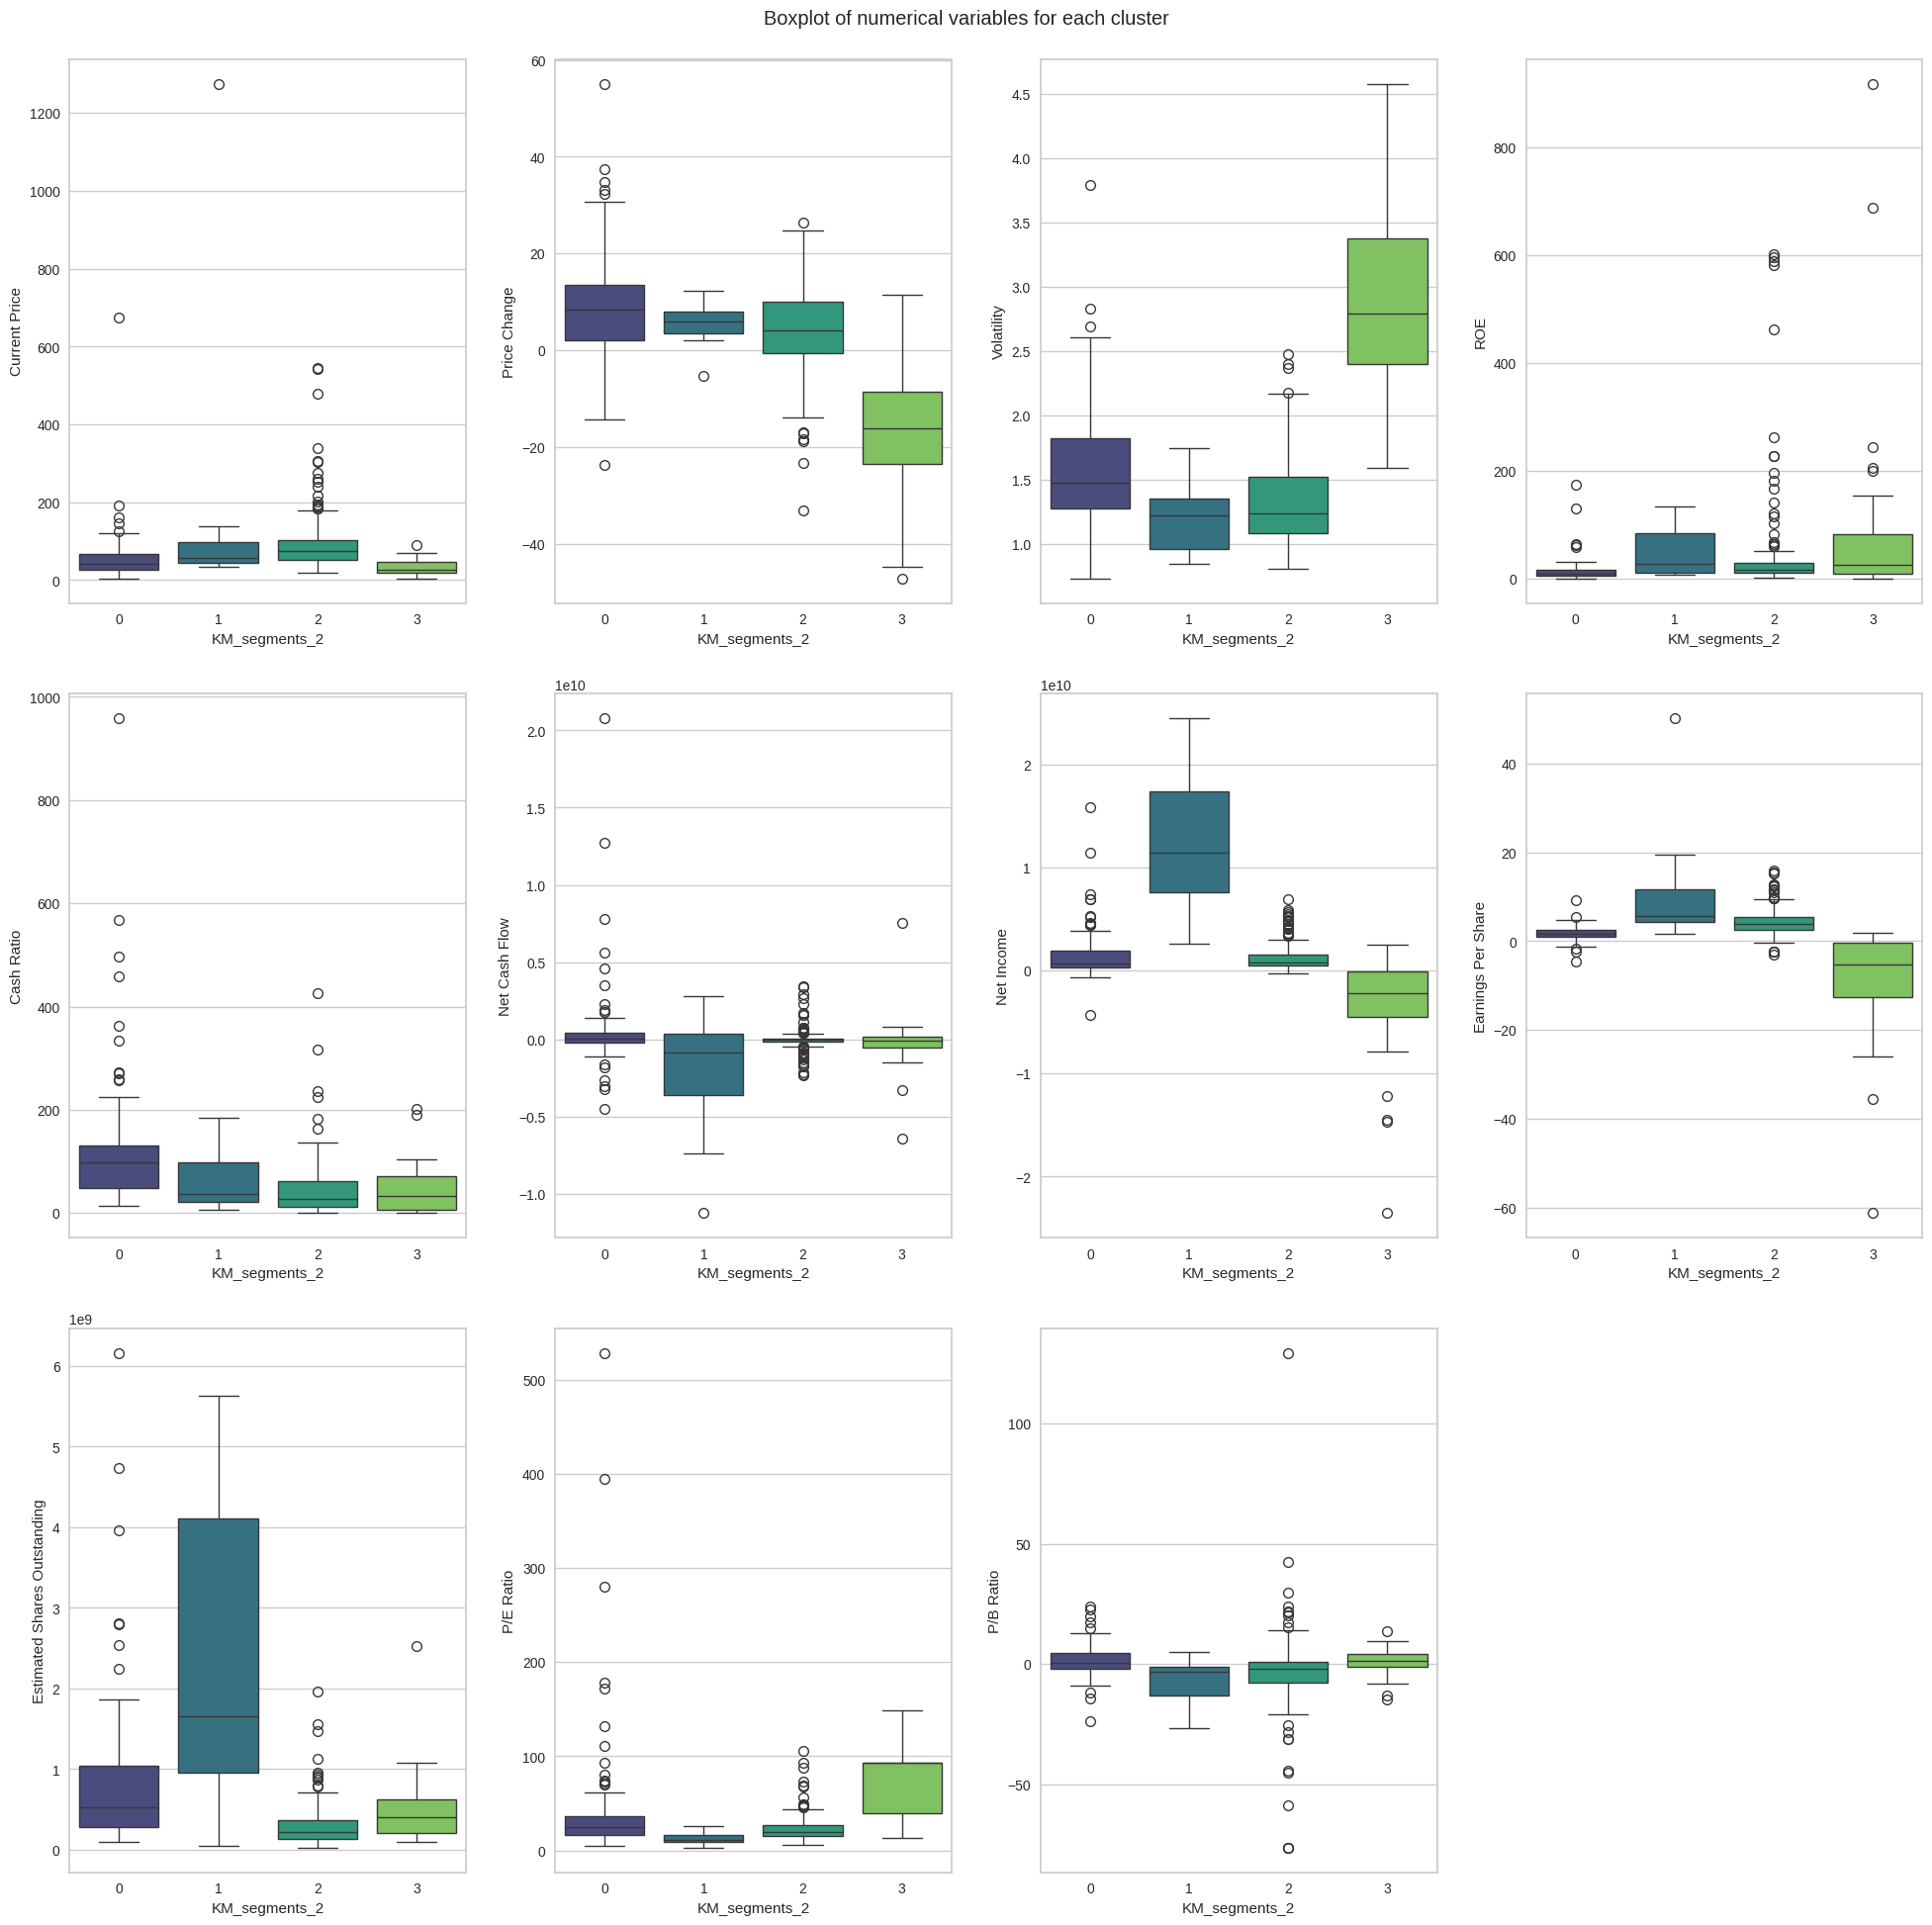

In [83]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

# selecting numerical columns
num_col_2 = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(num_col_2):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1_2, x="KM_segments_2", y=variable, palette='viridis')

plt.tight_layout(pad=2.0)

### Analysis: K-Means Clustering on Transformed Variables

* **Cluster 0 (102 companies)** includes a mix of Financials, Healthcare, and IT firms. These companies are moderately priced, relatively stable, and stand out for having the highest liquidity (cash ratios over 120) and strong positive cash flows. This group represents financially healthy firms with solid fundamentals and balanced risk.

* **Cluster 1 (16 companies)** is a much smaller cluster of speculative, high-priced companies. They have the highest average stock price, unusually high earnings per share, and very strong recent price gains. However, they also show negative cash flows and low liquidity. This suggests that these firms are **growth or momentum-driven**, with investors paying a premium despite weaker underlying fundamentals.

* **Cluster 2 (196 companies)** is the largest group, covering a broad spread of industries such as Industrials, Consumer Staples, Financials, and Utilities. These companies are profitable, have steady cash flows, and trade at moderate valuations. This is essentially the **mainstream cluster**, capturing the “average” market performer.

* **Cluster 3 (26 companies)** is dominated by the Energy sector (22 out of 26). These firms are characterized by very high volatility, strongly negative earnings, and sharply declining stock prices. At the same time, their ROE values are extremely high, which likely comes from accounting distortions (low equity bases). This cluster reflects **distressed and highly volatile outliers**, concentrated in Energy.

* Overall, the transformed data allows K-Means to create a **more nuanced segmentation** compared to the non-transformed version. Instead of just splitting the market into “mainstream vs. distressed,” the transformed features reveal four meaningful profiles: **financially healthy/liquid firms, speculative growth firms, mainstream market performers, and distressed Energy outliers.**



## **Hierarchical Clustering on Transformed Data**

### Computing Cophenetic Correlation

In [84]:
hc_df_2 = subset_scaled_df_2.copy()

In [85]:
# list of distance metrics
distance_metrics_2 = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods_2 = ["single", "complete", "average", "weighted"]

high_cophenet_corr_2 = 0
high_dm_lm_2 = [0, 0]

for dm in distance_metrics_2:
    for lm in linkage_methods_2:
        Z_2 = linkage(hc_df_2, metric=dm, method=lm)
        c_2, coph_dists_2 = cophenet(Z_2, pdist(hc_df_2))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c_2
            )
        )
        if high_cophenet_corr_2 < c_2:
            high_cophenet_corr_2 = c_2
            high_dm_lm_2[0] = dm
            high_dm_lm_2[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr_2, high_dm_lm_2[0].capitalize(), high_dm_lm_2[1]
    )
)

Cophenetic correlation for Euclidean distance and single linkage is 0.8494272658297587.
Cophenetic correlation for Euclidean distance and complete linkage is 0.5912950612399754.
Cophenetic correlation for Euclidean distance and average linkage is 0.8721427143249665.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.7051155711672615.
Cophenetic correlation for Chebyshev distance and single linkage is 0.788346892931323.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.6997444350714969.
Cophenetic correlation for Chebyshev distance and average linkage is 0.845778113638384.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.7597009627588145.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.8362618595475138.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.660453365887494.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.86122694166205.
Cophenetic correla

**Let's explore different linkage methods with Euclidean distance only.**

In [86]:
# list of linkage methods
linkage_methods_2 = ["single", "complete", "average", "centroid", "ward", "weighted"]
high_cophenet_corr_2 = 0
high_dm_lm_2 = [0, 0]

for lm in linkage_methods_2:
    Z_2 = linkage(hc_df_2, metric="euclidean", method=lm)
    c_2, coph_dists_2 = cophenet(Z_2, pdist(hc_df_2))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c_2))
    if high_cophenet_corr_2 < c_2:
        high_cophenet_corr_2 = c_2
        high_dm_lm_2[0] = "euclidean"
        high_dm_lm_2[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr_2, high_dm_lm_2[1]
    )
)

Cophenetic correlation for single linkage is 0.8494272658297587.
Cophenetic correlation for complete linkage is 0.5912950612399754.
Cophenetic correlation for average linkage is 0.8721427143249665.
Cophenetic correlation for centroid linkage is 0.8723962773936746.
Cophenetic correlation for ward linkage is 0.4656703716512288.
Cophenetic correlation for weighted linkage is 0.7051155711672615.
****************************************************************************************************
Highest cophenetic correlation is 0.8723962773936746, which is obtained with centroid linkage.


**Let's view the dendrograms for the different linkage methods with Euclidean distance.**

### Checking Dendrograms

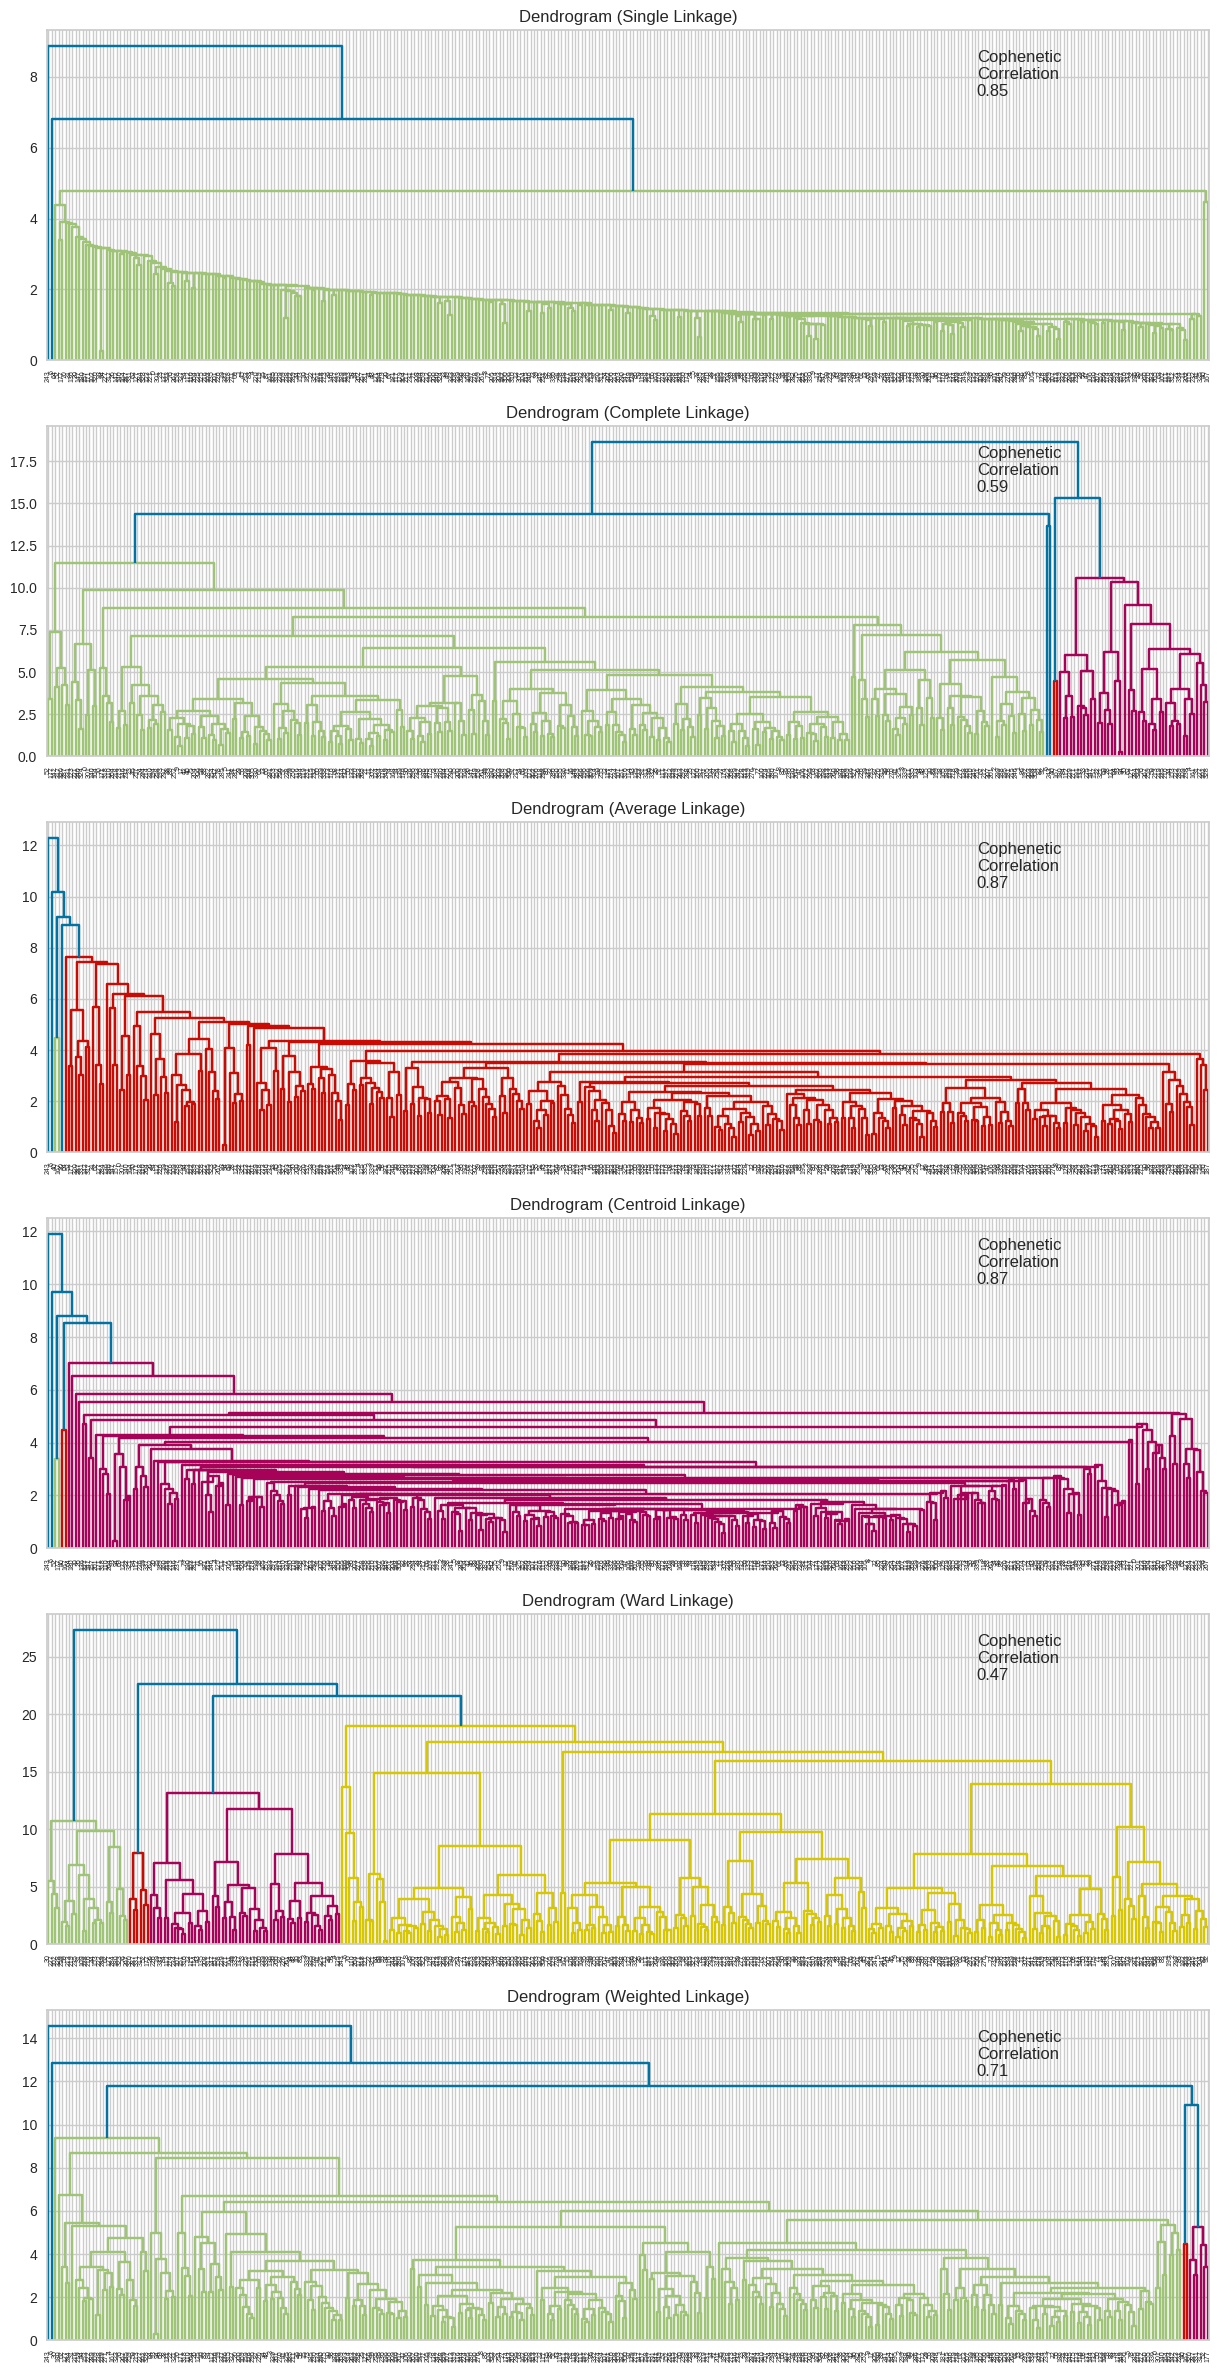

In [87]:
# list of linkage methods
linkage_methods_2 = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols_2 = ["Linkage", "Cophenetic Coefficient"]
compare_2 = []

# to create a subplot image
fig_2, axs_2 = plt.subplots(len(linkage_methods_2), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods_2):
    Z_2 = linkage(hc_df_2, metric="euclidean", method=method)

    dendrogram(Z_2, ax=axs_2[i])
    axs_2[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr_2, coph_dist_2 = cophenet(Z_2, pdist(hc_df_2))
    axs_2[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr_2:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare_2.append([method, coph_corr_2])

### Chooking k clusters

- Based on the Cophenetic Correlation, using Euclidean distance and average linkage gives a cophenetic correlation of 0.87, which is the highest among the tested options for this setup.

- From the dendrogram of Euclidean distance and average linkage, our options for k are the following:

  - **k = 2–3** if we cut very high (~10–12), we would get only very broad clusters, which are too general to be meaningful.

  - **k = 3–4** if we cut around ~8–9, we would obtain a reasonable number of clusters, capturing the main separations without over-fragmentation.

- We’ll proceed with k = 4, since cutting at ~8–9 produces clear, interpretable groups that align with the market structures we observed in our EDA.

In [88]:
# create and print a dataframe to compare cophenetic correlations for different linkage methods
df_cc_2 = pd.DataFrame(compare_2, columns=compare_cols_2)
df_cc_2 = df_cc_2.sort_values(by="Cophenetic Coefficient")
df_cc_2

,Linkage,Cophenetic Coefficient
4,ward,0.47
1,complete,0.59
5,weighted,0.71
0,single,0.85
2,average,0.87
3,centroid,0.87


### Creating model using sklearn

In [89]:
HCmodel_2 = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="average")
HCmodel_2.fit(hc_df_2)

AgglomerativeClustering(linkage='average', n_clusters=4)

In [90]:
# creating a copy of the original data
df2_2 = df.copy()

In [91]:
hc_df_2["HC_Clusters_2"] = HCmodel_2.labels_
df2_2["HC_Clusters_2"] = HCmodel_2.labels_

### Cluster Profiling

In [92]:
hc_cluster_profile_2 = df2_2.groupby("HC_Clusters_2")[hc_df_2.columns].mean()

In [93]:
hc_cluster_profile_2["count_in_each_segment"] = (
    df2_2.groupby("HC_Clusters_2")["Security"].count().values
)

In [94]:
hc_cluster_profile_2.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Estimated Shares Outstanding,Volatility,Cash Ratio,Net Income,Net Cash Flow,Earnings Per Share,Price Change,P/B Ratio,ROE,P/E Ratio,HC_Clusters_2,count_in_each_segment
HC_Clusters_2,,,,,,,,,,,,,
0,77.054754,566928835.548363,1.529172,69.458333,1421532333.333333,-38832464.285714,2.614509,4.031935,-2.128672,39.818452,32.751424,0.000000,336
1,25.640000,2791829362.100000,1.322355,130.500000,13654000000.000000,16755500000.000000,3.295000,11.237908,1.508484,12.500000,13.649696,1.000000,2
2,276.570007,66951851.850000,1.116976,25.000000,596541000.000000,90885000.000000,8.910000,6.189286,129.064585,30.000000,31.040405,2.000000,1
3,1274.949951,50935516.070000,1.268340,184.000000,2551360000.000000,-1671386000.000000,50.090000,3.190527,-1.052429,29.000000,25.453183,3.000000,1


In [95]:
## Printing the companies in each cluster
for cl in df2_2["HC_Clusters_2"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2_2[df2_2["HC_Clusters_2"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Alexion Pharmaceuticals' 'Applied Materials Inc' 'AMETEK Inc'
 'Affiliated Managers Group Inc' 'Amgen Inc' 'Ameriprise Financial'
 'American Tower Corp A' 'Amazon.com Inc' 'AutoNation Inc' 'Anthem Inc.'
 'Aon plc' 'Apache Corporation' 'Anadarko Petroleum Corp' 'Amphenol Corp'
 'Arconic Inc' 'Activision Blizzard' 'AvalonBay Communities, Inc.'
 'Broadcom' 'American Water Works Company Inc' 'American Express Co'
 'Boeing Company' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'Baker Hughes Inc' 'BIOGEN IDEC Inc.'
 'The Bank of New York

In [96]:
df2_2.groupby(["HC_Clusters_2", "GICS Sector"])['Security'].count()

HC_Clusters_2  GICS Sector                
0              Consumer Discretionary         39
               Consumer Staples               19
               Energy                         30
               Financials                     48
               Health Care                    40
               Industrials                    53
               Information Technology         31
               Materials                      20
               Real Estate                    27
               Telecommunications Services     5
               Utilities                      24
1              Financials                      1
               Information Technology          1
2              Information Technology          1
3              Consumer Discretionary          1
Name: Security, dtype: int64

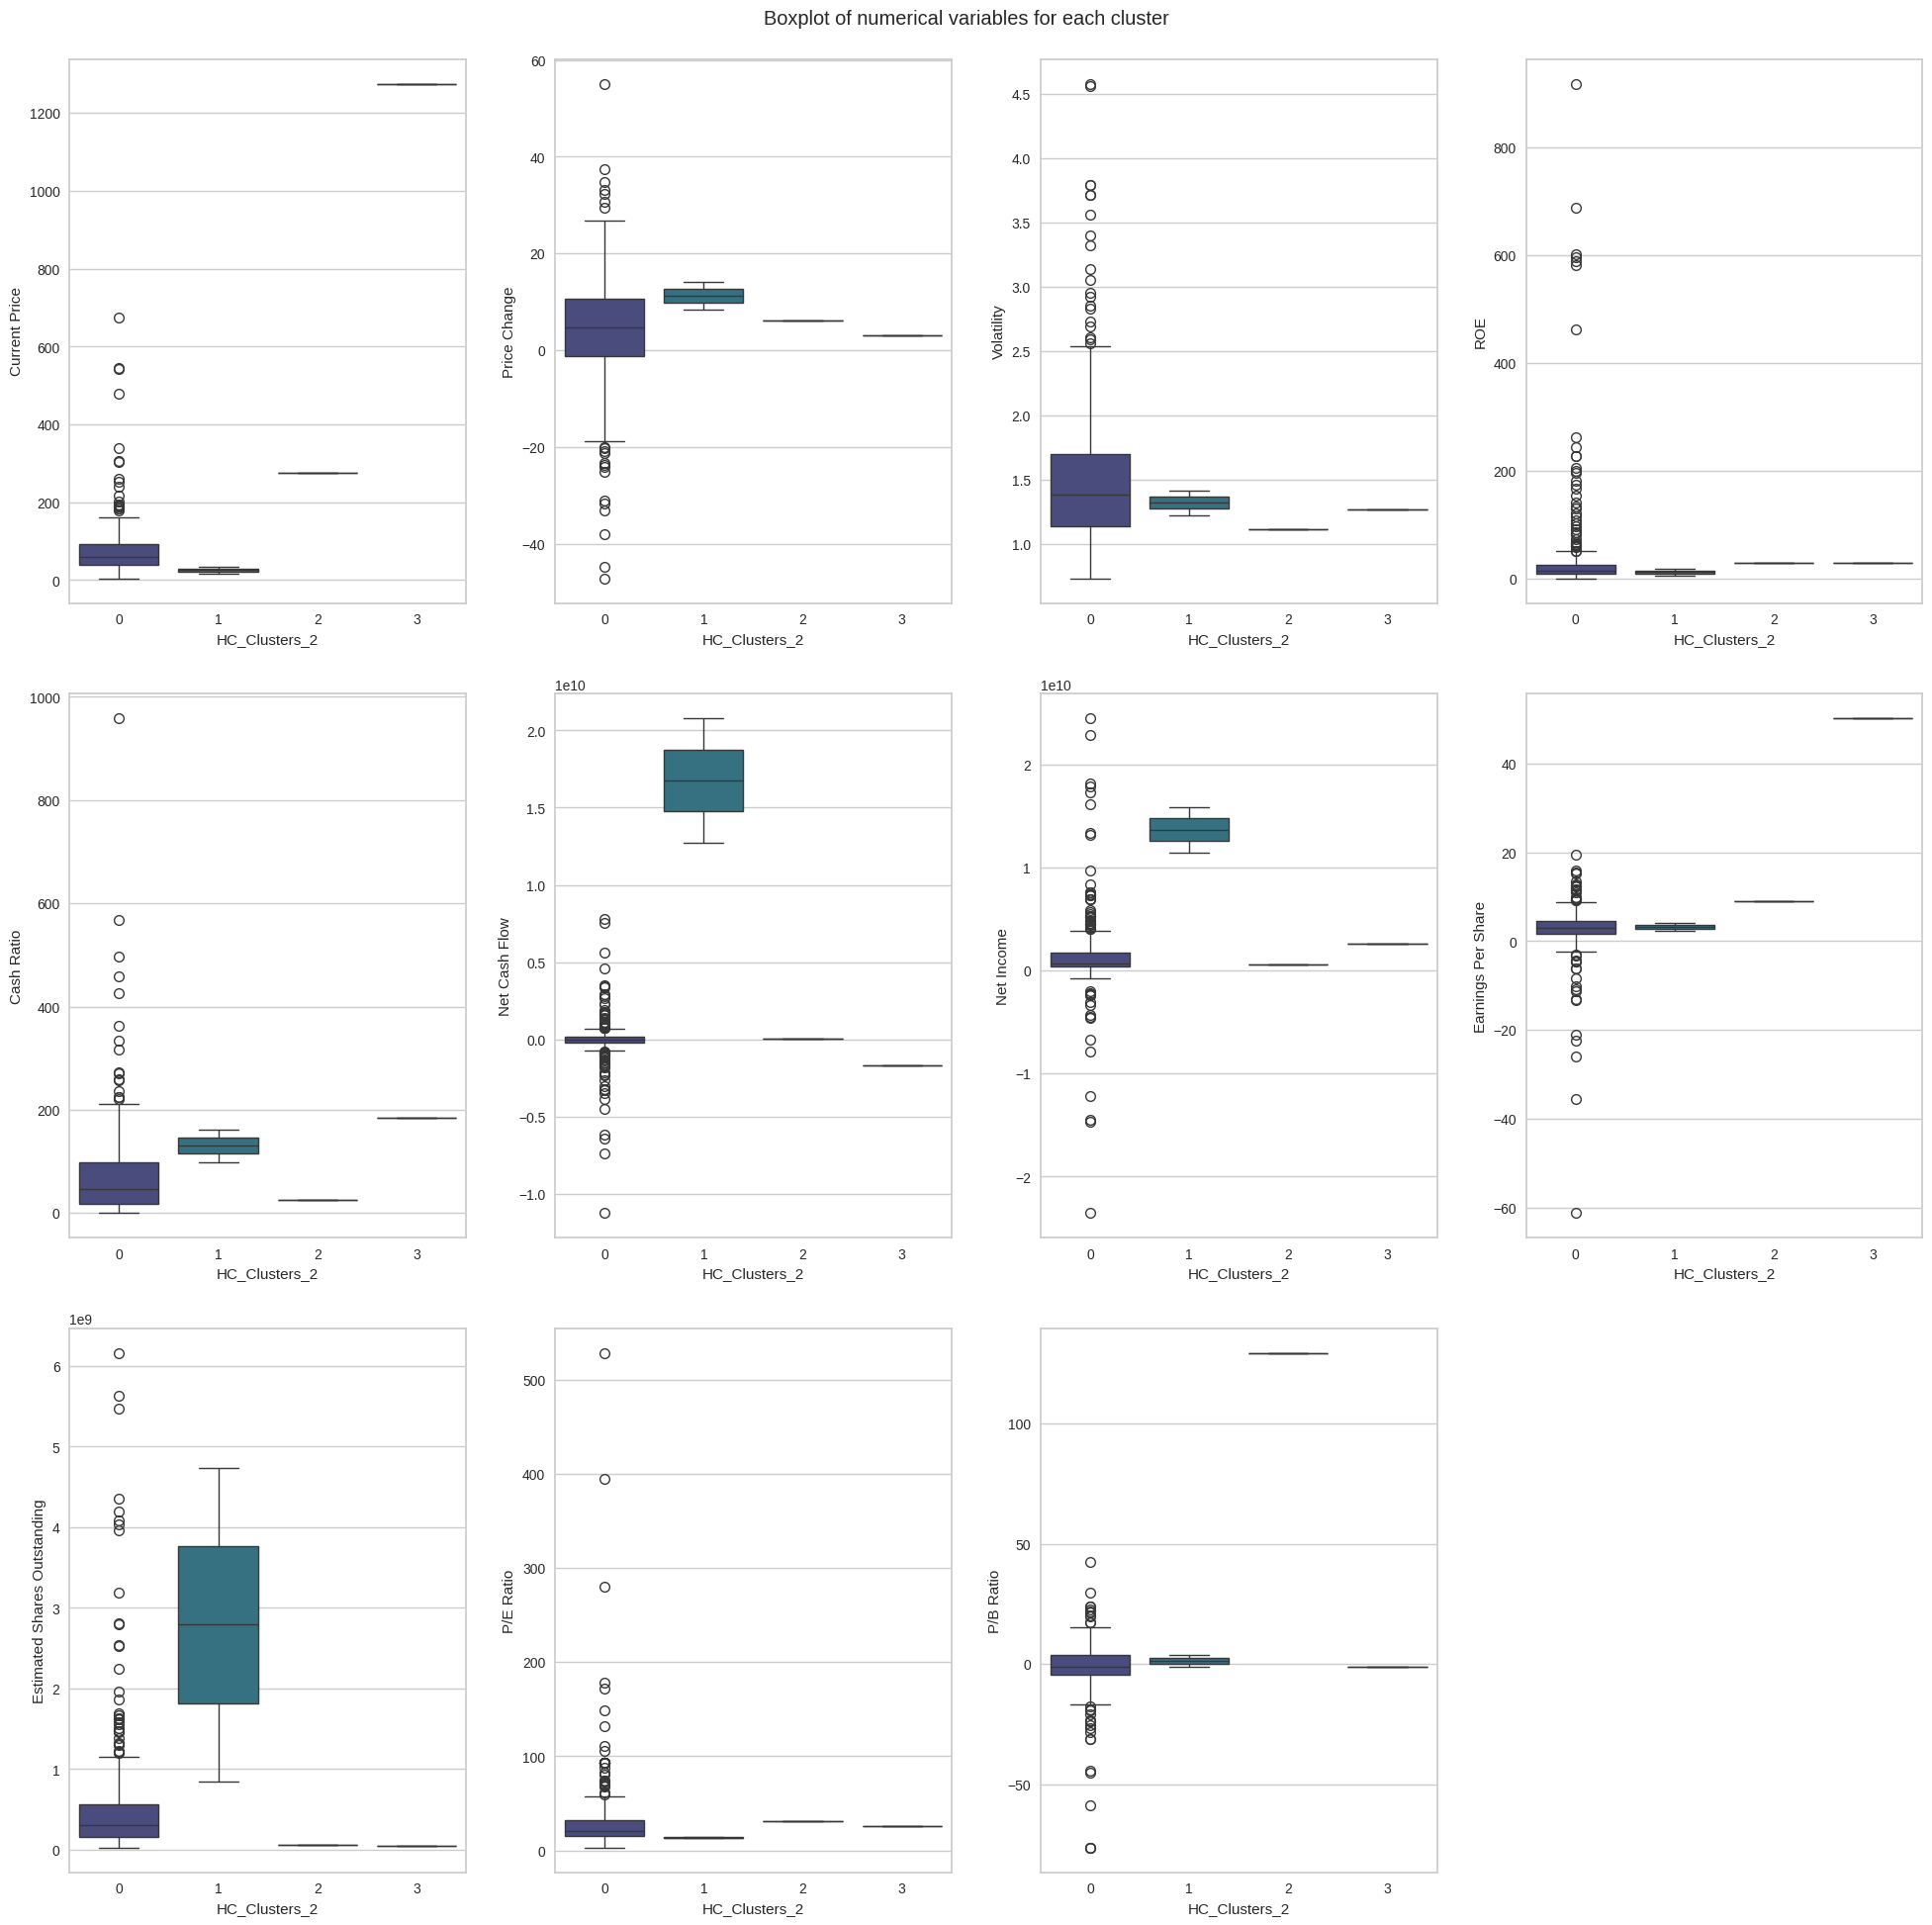

In [97]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(num_col_2):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2_2, x="HC_Clusters_2", y=variable, palette='viridis')

plt.tight_layout(pad=2.0)

### Analysis: Hierarchical Clustering on Transformed Variables

* **Cluster 0 (336 companies)** forms the large, mainstream group that contains almost all sectors. These firms are moderately priced, show positive net income, and have stable volatility and returns. Financials, Industrials, Healthcare, and Consumer sectors make up the bulk of this cluster. It essentially represents the **average, stable segment of the market.**

* **Cluster 1 (2 companies)** is a very small group with unusual financial traits. These firms have extremely high cash ratios, positive price changes, and strong valuations, suggesting they are **unique outliers that investors view as highly liquid and promising.**

* **Cluster 2 (1 company)** is an isolated outlier from the Information Technology sector. It has unusually high prices, strong EPS, and high P/B ratio, separating it from the rest of the dataset.

* **Cluster 3 (1 company)** is another extreme outlier, in this case from Consumer Discretionary. It is defined by an extraordinary stock price (over 1200) and unusually strong EPS, making it a very atypical firm compared to the rest.

* Overall, the transformed data still suffers from the issue of **one giant cluster plus a few single-company outliers**. While Cluster 0 provides a clear mainstream group, the other clusters are too small to be truly meaningful. This suggests that **hierarchical clustering on transformed features struggles to find balanced segments**, in contrast to K-Means, which produced four well-differentiated financial profiles.

* In this case, **Hierarchical (transformed) showed weaken performance than K-Means (transformed)** because it collapsed almost everything into one group, leaving only extreme outliers isolated.


**Why K-Means Outperformed Hierarchical on Transformed Features**

- K-Means creates more balanced groups, while Hierarchical often results in one large cluster and a few outlier clusters.

- K-Means is less sensitive to outliers on scaled data, whereas Hierarchical tends to isolate outliers into their own small clusters.

- Scaling helps K-Means maintain separation, but Hierarchical can end up lumping firms together as too similar.

- In high dimensions, K-Means adapts through centroid optimization, while Hierarchical struggles since it relies only on raw distances.



# **9. Overall Analysis: K-Means vs Hierarchical (Transformed vs Non-Transformed)**

In order to help investors build diversified portfolios and identify stocks with similar financial and market behavior, we compared the performance of **K-Means** and **Hierarchical clustering** on both raw (non-transformed) and transformed features.

* **Execution time:**

  * K-Means consistently took less time to run, making it more practical for large-scale investment screening.
  * Hierarchical clustering was slower because it computes all pairwise distances and builds a dendrogram, which is computationally heavier.

* **Distinctness of clusters:**

  * With non-transformed data, both algorithms produced sector-driven clusters, heavily influenced by Energy stocks. K-Means gave only two groups (mainstream vs distressed), while Hierarchical gave four, but they were essentially “one large mainstream cluster and a few small anomaly clusters.”
  * With transformed data, K-Means produced four **well-separated financial profiles**:

    1. Mainstream stable companies
    2. Growth/speculative firms with high valuations
    3. Liquidity-strong companies with high cash ratios
    4. Distressed Energy-heavy firms
  * Hierarchical clustering on transformed data performed poorly, merging almost all companies into a single group and only isolating a handful of outliers.

* **Similarity of observations:**

  * On non-transformed features, both algorithms largely agreed that the bulk of firms belonged to the mainstream cluster, and that Energy firms were the main outliers.
  * On transformed features, overlap was minimal. K-Means allocated companies across four meaningful groups, while Hierarchical still lumped most of them together.

* **Appropriate number of clusters:**

  * For non-transformed data: K-Means worked best with **k=2**, while Hierarchical suggested 3–4 clusters. In either case, the clusters were imbalanced.
  * For transformed data: K-Means worked best with **k=4**, producing realtively balanced and interpretable financial profiles. Hierarchical (even at k=4) gave one very large cluster and three tiny ones, which is not useful for portfolio diversification.

* **Business takeaway:**

  * Hierarchical clustering helped **highlight the dominance of Energy-sector volatility** when working with raw financial data, but it failed to produce balanced groups with transformed features.
  * K-Means clustering, especially on transformed features, was the **most effective approach**. It provided balanced clusters that clearly separated growth stocks, stable mainstream firms, liquidity-strong companies, and distressed firms. These insights are much more actionable for building **diversified investment portfolios**, since they allow investors to spread risk across distinct financial profiles rather than just across sectors.



# **10. Executive Summary**

## **Conclusion**



* The exploratory data analysis showed that **sector differences, especially in Energy, often stood out as outliers** in returns, volatility, and valuations. Other indicators like P/E ratio, ROE, and cash flow revealed meaningful patterns but required transformation to show clearer separations.

* Among the methods tested, the **most effective segmentation came from K-Means clustering on transformed features with k = 4**. This produced four interpretable profiles: mainstream stable firms, speculative growth stocks, liquidity-strong firms, and distressed outliers (dominated by Energy).

* **Hierarchical clustering struggled to form balanced clusters**, often collapsing most firms into a single group and isolating only a few outliers—especially after transformations. On raw data, it captured some sector-driven differences but lacked nuance.

* **K-Means clearly outperformed Hierarchical** in terms of speed, balance, and interpretability, while transformations (log / Yeo–Johnson) were essential for uncovering financial groupings that aligned with business insights.

* The choice of **k was subjective and highly sensitive** to scaling, transformations, and linkage methods, emphasizing the importance of careful methodology.

* Overall, **K-Means with transformed features (k = 4)** provided Trade\&Ahead with the clearest, most actionable segmentation—offering a scalable way to classify stocks into distinct investment profiles that support diversification and informed portfolio strategies.


## **Actionable Insights for Trade & Ahead**







- **Four financial profiles were identified:** mainstream stable companies, speculative growth firms, liquidity-strong firms, and distressed outliers (Energy-heavy).

- Investors can use these clusters to diversify across financial behaviors, not just industry sectors, improving risk management.

- The **mainstream cluster** represents safe, long-term investment opportunities with moderate growth and profitability.

- The **speculative cluster** shows high short-term growth potential but comes with higher risk due to weaker fundamentals.

- The **liquidity-strong cluster** includes companies with strong cash reserves and steady cash flow, making them more resilient in downturns and attractive for defensive portfolio positions.

- The **distressed cluster** signals companies that should be treated cautiously, as they exhibit volatility, negative earnings, or valuation distortions.

## **Recommendations for Trade & Ahead**

- Based on the given dataset, Trade & Ahead should adopt K-Means clustering on transformed features (k=4) as the standard approach for client portfolio analysis.

- Investors should **combine stocks from each cluster to maximize diversification** and reduce exposure to sector-specific downturns.

- **Regularly re-run the clustering process** (quarterly or bi-annually) to capture market shifts and update investment strategies.

- Create **client-facing reports** that explain stock groups in plain language (e.g., “growth-oriented” vs “stable-income”) to support decision-making.

- Consider expanding the dataset with **additional financial indicators** (e.g., debt ratios, dividend yield) to enrich cluster insights.

## **Limitations of the Models**

- Hierarchical clustering **did not produce balanced results** on transformed features, limiting its usefulness for this dataset.

- The analysis was based on a **snapshot of financial data**; clusters may shift with changing market conditions.

- **Outlier companies** dominated certain clusters (e.g., Energy sector), which may bias interpretations.

- Choosing k was **subjective and highly sensitive** to factors such as scaling, transformations, and distance metrics. Different settings could lead to different cluster structures.

- The dataset only included **selected financial metrics**; other relevant factors like macroeconomic conditions or forward-looking growth expectations were not considered.